# Group 4 | Nancy Melchert, Sophia Menchaca, Blythe Weng

## Galaxy Classification

# INFORMATION ABOUT THE DATASET

From the [zenodo.org](https://zenodo.org/records/11117528) site:

## Overview

GalaxiesML is a machine learning-ready dataset of galaxy images, photometry, redshifts, and structural parameters. It is designed for machine learning applications in astrophysics, particularly for tasks such as redshift estimation and galaxy morphology classification. The dataset comprises **286,401 galaxy images** from the Hyper-Suprime-Cam (HSC) Survey PDR2 in five filters: g, r, i, z, y, with spectroscopically confirmed redshifts as ground truth.

This dataset is particularly useful for developing machine learning models for upcoming large-scale surveys like **LSST** and **Euclid**.

## Features

- **286,401 galaxy images** in five photometric bands (g, r, i, z, y).
- Spectroscopic redshifts for each galaxy, with redshift values ranging from **0.01 to 4**.
- Morphological parameters derived from galaxy images, including **Sérsic index**, **half-light radius**, and **ellipticity**.
- **Machine learning-friendly formats**: images are provided in **HDF5** format, along with CSV metadata.


## Examples of Using GalaxiesML

Examples of uses of GalaxiesML are outlined in Do et al. (2024). The repository for example code are here:

https://github.com/astrodatalab/galaxiesml_examples


## Citation

Please cite the following papers if you use this dataset in your work:

1. **GalaxiesML Dataset**:
- Do, T. et al., *GalaxiesML: A Dataset of Galaxy Images, Photometry, Redshifts, and Structural Parameters for Machine Learning*. arXiv:2410.00271 (2024), https://arxiv.org/abs/2410.00271 

2. **Hyper Suprime-Cam Subaru Strategic Program (HSC PDR2)**:
- Aihara, H., et al., *Second Data Release of the Hyper Suprime-Cam Subaru Strategic Program*. Publications of the Astronomical Society of Japan, 71(6), 114 (2019). DOI: [10.1093/pasj/psz103](https://doi.org/10.1093/pasj/psz103)

3. **Spectroscopic Surveys**:
- Several publicly available spectroscopic redshift catalogs were used in creating this dataset. Notable sources include:
- **zCOSMOS Survey**: Lilly, S. J., et al., *The zCOSMOS 10k-Bright Spectroscopic Sample*. The Astrophysical Journal Supplement Series, 184(2), 218-229 (2009). DOI: [10.1088/0067-0049/184/2/218](https://doi.org/10.1088/0067-0049/184/2/218)
- **VIMOS Public Extragalactic Survey (VIPERS)**: Garilli, B., et al., *The VIMOS Public Extragalactic Survey (VIPERS): First Data Release of 57,204 Spectroscopic Measurements*. Astronomy & Astrophysics, 562, A23 (2014). DOI: [10.1051/0004-6361/201322790](https://doi.org/10.1051/0004-6361/201322790)
- **DEEP2 Survey**: Newman, J. A., et al., *The DEEP2 Galaxy Redshift Survey: Design, Observations, Data Reduction, and Redshifts*. The Astrophysical Journal Supplement Series, 208(1), 5 (2013). DOI: [10.1088/0067-0049/208/1/5](https://doi.org/10.1088/0067-0049/208/1/5)


## How to Access

The dataset is publicly available on **Zenodo** with the DOI: **[10.5281/zenodo.11117528](https://doi.org/10.5281/zenodo.11117528)**.

## License

This dataset is licensed under a **Creative Commons Attribution 4.0 International License (CC BY 4.0)**. You are free to share and adapt the dataset as long as appropriate credit is given. For more details, visit: **[CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)**.

Please cite the references mentioned above if you use this dataset in your work.

THIS IS TO SEE IF I CAN FIGURE OUT THE PUSH/PULL AND GET IT INTO THE MAIN BRANCH

# Install and import necessary libraries

In [70]:
# %pip install jupyter nbconvert


In [31]:
# %pip install astropy
# %pip install scipy
# %pip install seaborn
# %pip install scikit-learn

In [28]:
# install appropriate libraries
# TODO: Move all imported libraries to the top of the file and install them if they are not already installed
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import Tk, filedialog

# H5PY is used for reading the .h5py files containing the galaxy images
try:
    import h5py
except ImportError: 
    %pip install h5py

# PyTorch is used for building the convolutional neural network
try:
    import torch
except ImportError:
    %pip install torch

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms


In [29]:

# Check for NVIDIA GPU, then Apple Silicon GPU, then default to CPU for training the CNN
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [30]:
# Install Hugging Face datasets
%matplotlib inline
try:
    from datasets import load_dataset
except ImportError:
    %pip install datasets

# DOWNLOAD AND EXPLORE THE DATASET

Datasets are `.hdf5`. The h5py package is a Pythonic interface to the HDF5 binary data format. 
[H5PY Documentation](https://docs.h5py.org/en/stable/)

## MLGalaxies Data

In [31]:
# CoPilot helped with this code snippet to create a custom PyTorch Dataset class for loading
class GalaxyDataset(Dataset):
    def __init__(self, hdf5_path, image_key="image", labels_npy_path=None, indices_npy_path=None):
        self.hdf5_path = hdf5_path
        self.image_key = image_key
        self.labels = np.load(labels_npy_path) if labels_npy_path else None
        self.indices = np.load(indices_npy_path) if indices_npy_path else None

        # Open the file to get the length of the dataset, then close it
        with h5py.File(self.hdf5_path, "r") as f:
            self.image_count = f[self.image_key].shape[0]
    
        if self.indices is None:
            self.indices = np.arange(self.image_count)
        else:
            self.indices = self.indices.astype(np.int64)

        # Drop indices that do not exist in this HDF5 split
        valid_mask = (self.indices >= 0) & (self.indices < self.image_count)
        if not np.all(valid_mask):
            dropped = int((~valid_mask).sum())
            print(f"Dropping {dropped} out-of-range indices for {os.path.basename(self.hdf5_path)}")
            self.indices = self.indices[valid_mask]
            if self.labels is not None:
                self.labels = self.labels[valid_mask]

        if self.labels is not None and len(self.labels) != len(self.indices):
            raise ValueError(f"labels ({len(self.labels)}) and indices ({len(self.indices)}) must match")

        self.length = len(self.indices)
        self.file = None  # Will hold the open HDF5 file

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        if self.file is None:
            # Open the file inside the active process
            self.file = h5py.File(self.hdf5_path, "r")

        #Extract data (HDF5 slicing loads only this slice into RAM)    
        image = self.file[self.image_key][idx]
        img_tensor = torch.tensor(image, dtype=torch.float32)

        if self.labels is None:
            return img_tensor
        
        label = self.labels[idx]
        label_tensor = torch.tensor(label, dtype=torch.long) if label is not None else None

        return img_tensor, label_tensor


In [32]:
#Refactor of selection code to be able to reuse this code for validation and testing datasets as well
def select_hdf5_file(title="Select HDF5 file"):
    """
    Opens a file dialog to select an HDF5 file and returns the selected file path.
    Raises a ValueError if no file is selected.
    """
    Tk().withdraw()  # Hide the main window
    Tk().attributes("-topmost", True)  # Bring the file dialog to the front

    hdf5_path = filedialog.askopenfilename(
        title=title, 
        filetypes=[("HDF5 files", "*.hdf5"), ("All files", "*.*")])

    Tk().destroy()  # Close the file dialog

    if not hdf5_path:
        raise ValueError("No file selected. Please select an HDF5 file.")
    
    return hdf5_path
#hdf5_path = "data/training_sample_1000.hdf5"
def inspect_hdf5_file(hdf5_path):
    """
    Opens the selected HDF5 file and prints the keys available in the file.
    Returns the list of keys.
    """
    with h5py.File(hdf5_path, "r") as f:
        keys = list(f.keys())
    print(f"Selected file: {hdf5_path}")
    print("Keys in the HDF5 file:", keys)
    return keys

def make_dataset_and_loader(hdf5_path, image_key="image", labels_npy_path="clean_labels.npy", indices_npy_path="clean_indices.npy", batch_size=32, shuffle=True):
    """
    Creates a PyTorch Dataset and DataLoader for the given HDF5 file and associated labels/indices.
    Returns the dataset and dataloader.
    """
    dataset = GalaxyDataset(hdf5_path, image_key=image_key, labels_npy_path=labels_npy_path, indices_npy_path=indices_npy_path)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    print(f"Total Images: {len(dataset)}")
    return dataset, loader

In [33]:
# Function to visualize a sample image from the dataset along with its label (if available)
# The default of (g, r, i, z, y) is for the land-based telescope images that use 5-band photometric filters.
# Enter band names for the jwst to use this function for the jwst images as well.

def print_image(idx=0, dataset=None, band_names=("g", "r", "i", "z", "y"), cmap = "gray_r"):
    """Visualizes a sample image from the dataset along with its label (if available).
    Args:        
        idx (int): Index of the sample to visualize.
        dataset (GalaxyDataset): An instance of the GalaxyDataset class containing the images and labels.
        band_names (tuple): Optional tuple of band names corresponding to the image channels for labeling the plots.
    Raises:        
        ValueError: If the dataset is not provided or if the sample format is unexpected.
    Returns:
        None: Displays the image using matplotlib.
    """

    if dataset is None:
        raise ValueError("Pass your GalaxyDataset instance, e.g., print_image(0, dataset)")

    sample = dataset[idx]
    
    # Support both image-only and (image, label) dataset outputs
    if isinstance(sample, (tuple, list)):
        img_tensor = sample[0]
        label = sample[1] if len(sample) > 1 else None
    else:
        img_tensor = sample
        label = None

    label_text = f"class {int(label)}" if label is not None else None
    flux = img_tensor.detach().cpu().numpy()  # expected shape: (C, H, W)

    plt.figure(figsize=(12, 3))
    for i in range(flux.shape[0]):
        plt.subplot(1, flux.shape[0], i + 1)
        title = band_names[i] if i < len(band_names) else f"band {i}"
        if i == 0 and label_text is not None:
            title = f"{label_text} \n {title} "
        plt.title(title)
        plt.imshow(flux[i], cmap=cmap, origin="lower")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [34]:
# Use the refactored selection function to select the training, testing, and validation HDF5 files from
# where the user saves them on their computer. 
# This allows us to avoid hardcoding file paths and makes the code more flexible and reusable, but does not work
# on the Great Lakes environment. If using Great Lakes, you will likely need to hardcode the file paths to the HDF5 files on 
# that system, or use a different method to select the files.

# These variables will hold the file paths to the selected HDF5 files for training, testing, and validation datasets
train_hdf5 = select_hdf5_file("Select training HDF5")
test_hdf5 = select_hdf5_file("Select testing HDF5")
validation_hdf5 = select_hdf5_file("Select validation HDF5")
# train_hdf5 = hdf5_path
# validation_hdf5 = hdf5_path

In [35]:
inspect_hdf5_file(train_hdf5)

Selected file: /Volumes/NMELCHERT/MLGalaxies/5x127x127_training_with_morphology.hdf5
Keys in the HDF5 file: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness'

['coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'image',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 'skym

### Creating Labels for the images based on the morphology columns in the CSV file

In [14]:
# csv files are inside a data folder, but then in .gitignore because of the size, so we need to specify the path to read them
# These CSV files are only the morphology data, not the image data.
images_morphology_df = pd.read_csv("data/5x127x127_training_with_morphology.csv")
print("CSV DataFrame shape:", images_morphology_df.shape)


CSV DataFrame shape: (204573, 84)


Ref: https://academic.oup.com/mnras/article/529/1/499/7609698 <br>
Ref: https://www.aanda.org/articles/aa/full_html/2023/01/aa45268-22/aa45268-22.html

<u>Typical Sérsic Ranges and Morphology</u>

n ≈ 0.5 to 1: Late-Type Galaxies (LTGs) / Disks. 
>Exponential light distribution with a low degree of central concentration. These are primarily spiral and irregular galaxies with highly active star formation.

n ≈ 1 to 2.5: Pseudobulges / Transition Objects. 
>These often represent late-type spirals with significant central bulges or dwarf elliptical galaxies.

n ≈ 2.5 to 4: Early-Type Galaxies (ETGs) / Classical Bulges. 
>High central concentration with less light in the outer regions. Typical for standard elliptical galaxies and massive bulges.

n > 4: Giant Elliptical Galaxies & Brightest Cluster Galaxies (BCGs). 
>Highly concentrated, massive, and quiescent systems with extremely steep light profiles.

In [16]:
# Reusable labeling utilities for train/validation/test splits based on r_sersic_index
from pathlib import Path

# Class mapping used by the model (num_classes = 5):
# 0 = LTG / Disk (0.5 <= n < 1.0)
# 1 = Pseudobulge / Transition (1.0 <= n < 2.5)
# 2 = ETG / Classical Bulge (2.5 <= n <= 4.0)
# 3 = Giant Elliptical / BCG (n > 4.0)
# 4 = Irregular (n < 0.5)

CLASS_NAMES = {
    0: "LTG / Disk",
    1: "Pseudobulge / Transition",
    2: "ETG / Classical Bulge",
    3: "Giant Elliptical / BCG",
    4: "Irregular",
    5: "Unknown / Invalid n"
}

def build_sersic_labels(df, sersic_col="r_sersic_index", keep_unknown=False):
    """Build labels and aligned row indices from a morphology dataframe.

    If keep_unknown is False, rows with non-finite Sérsic values are dropped.
    If keep_unknown is True, those rows are kept with class 5.
    """
    if sersic_col not in df.columns:
        raise KeyError(f"Column '{sersic_col}' not found in dataframe")

    n = df[sersic_col].to_numpy()
    valid_n = np.isfinite(n)

    labels = np.full(len(df), 5, dtype=np.int64)  # default unknown/invalid
    labels[(n >= 0.5) & (n < 1.0)] = 0
    labels[(n >= 1.0) & (n < 2.5)] = 1
    labels[(n >= 2.5) & (n <= 4.0)] = 2
    labels[(n > 4.0)] = 3
    labels[(n < 0.5)] = 4

    if keep_unknown:
        keep_mask = np.ones(len(df), dtype=bool)
    else:
        keep_mask = valid_n

    clean_indices = np.where(keep_mask)[0].astype(np.int64)
    final_labels = labels[keep_mask].astype(np.int64)
    final_df = df.iloc[clean_indices].copy()

    return clean_indices, final_labels, final_df

def save_split_labels(csv_path, split_name, sersic_col="r_sersic_index", keep_unknown=False, out_dir="."):
    """Create and save <split>_indices.npy and <split>_labels.npy from one CSV."""
    df = pd.read_csv(csv_path)
    clean_indices, final_labels, final_df = build_sersic_labels(
        df, sersic_col=sersic_col, keep_unknown=keep_unknown
    )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    idx_path = out_dir / f"{split_name}_indices.npy"
    lbl_path = out_dir / f"{split_name}_labels.npy"
    np.save(idx_path, clean_indices)
    np.save(lbl_path, final_labels)

    class_counts = {
        CLASS_NAMES[k]: int(np.sum(final_labels == k))
        for k in np.unique(final_labels)
    }

    print(f"[{split_name}] source rows: {len(df):,}")
    print(f"[{split_name}] kept rows:   {len(final_df):,}")
    print(f"[{split_name}] dropped rows: {len(df) - len(final_df):,}")
    print(f"[{split_name}] saved: {idx_path.name}, {lbl_path.name}")
    print(f"[{split_name}] class counts: {class_counts}")

    return {
        "split": split_name,
        "csv_path": csv_path,
        "indices_path": str(idx_path),
        "labels_path": str(lbl_path),
        "kept_rows": len(final_df),
        "dropped_rows": len(df) - len(final_df),
        "class_counts": class_counts,
    }


In [53]:
# Build labels for all splits with one consistent rule set
split_csvs = {
    "train": "data/5x127x127_training_with_morphology.csv",
    "validation": "data/5x127x127_validation_with_morphology.csv",
    "test": "data/5x127x127_testing_with_morphology.csv",
}

summaries = {}
for split_name, csv_path in split_csvs.items():
    summaries[split_name] = save_split_labels(
        csv_path=csv_path,
        split_name=split_name,
        sersic_col="r_sersic_index",
        keep_unknown=False,  # keep this False to match num_classes=5
        out_dir="."
    )

[train] source rows: 204,573
[train] kept rows:   204,573
[train] dropped rows: 0
[train] saved: train_indices.npy, train_labels.npy
[train] class counts: {'LTG / Disk': 56057, 'Pseudobulge / Transition': 121927, 'ETG / Classical Bulge': 19061, 'Giant Elliptical / BCG': 2398, 'Irregular': 5130}
[validation] source rows: 40,914
[validation] kept rows:   40,914
[validation] dropped rows: 0
[validation] saved: validation_indices.npy, validation_labels.npy
[validation] class counts: {'LTG / Disk': 11084, 'Pseudobulge / Transition': 24456, 'ETG / Classical Bulge': 3921, 'Giant Elliptical / BCG': 472, 'Irregular': 981}
[test] source rows: 40,914
[test] kept rows:   40,914
[test] dropped rows: 0
[test] saved: test_indices.npy, test_labels.npy
[test] class counts: {'LTG / Disk': 11069, 'Pseudobulge / Transition': 24465, 'ETG / Classical Bulge': 3906, 'Giant Elliptical / BCG': 466, 'Irregular': 1008}


In [62]:
# Build Sérsic-based labels
clean_indices, final_labels, labeled_images_df = build_sersic_labels(
    images_morphology_df,
    sersic_col="r_sersic_index",
    keep_unknown=False
)

In [63]:
# Add labels as a column
labeled_images_df["galaxy_type"] = final_labels
labeled_images_df = labeled_images_df.drop('r_sersic_index', axis=1)	

labeled_images_df["galaxy_type"] = final_labels
labeled_images_df["galaxy_type_name"] = (
    labeled_images_df["galaxy_type"]
    .map(CLASS_NAMES)
)

labeled_images_df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,galaxy_type,galaxy_type_name
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146,1,Pseudobulge / Transition
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576,1,Pseudobulge / Transition
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096,1,Pseudobulge / Transition
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943,1,Pseudobulge / Transition
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187,1,Pseudobulge / Transition


In [64]:
labeled_images_df['g_sersic_index'].iloc[35]

np.float64(0.843)

In [23]:
labeled_images_df['specz_name'].head()
sdss_image_finder_cols = [
    'specz_name',
    'skymap_id',
    'specz_ra',
    'specz_dec',
    'object_id']

sdss_image_finder_df = labeled_images_df[sdss_image_finder_cols].copy()
sdss_image_finder_df.head()

,specz_name,skymap_id,specz_ra,specz_dec,object_id
0,b'SDSS-DR12-1237679340566282311',82780004,29.099590,-6.616872,36407046198791272
1,b'SDSS-DR12-1237679439348826794',82780004,29.158636,-6.701283,36407046198803509
2,b'SDSS-DR12-1237679340566282837',82780005,29.199664,-6.438590,36407050493759629
3,b'SDSS-DR12-1237679439885697326',82780005,29.092156,-6.422376,36407050493760107
4,b'SDSS-DR12-1237679340566282840',82780005,29.208631,-6.587672,36407050493771757


galaxy_type_name
ETG / Classical Bulge        19061
Giant Elliptical / BCG        2398
Irregular                     5130
LTG / Disk                   56057
Pseudobulge / Transition    121927
Name: count, dtype: int64


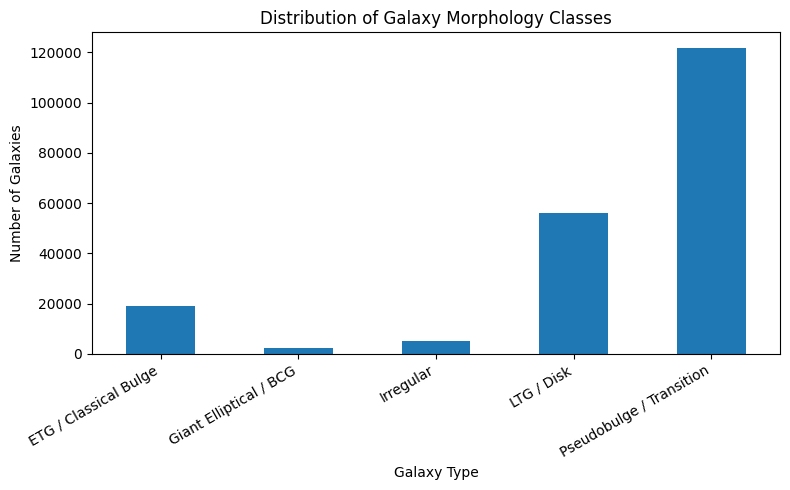

In [13]:
# Plot the distribution of galaxy types within the dataset
import matplotlib.pyplot as plt

class_counts = (
    labeled_images_df["galaxy_type_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")

plt.title("Distribution of Galaxy Morphology Classes")
plt.xlabel("Galaxy Type")
plt.ylabel("Number of Galaxies")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [38]:
# Use created indices and label files to create the PyTorch Dataset and DataLoader for the training dataset
dataset, loader = make_dataset_and_loader(
    train_hdf5, 
    image_key="image", 
    labels_npy_path="train_labels.npy",
    indices_npy_path="train_indices.npy",
    batch_size=32, 
    shuffle=True)


Total Images: 204573


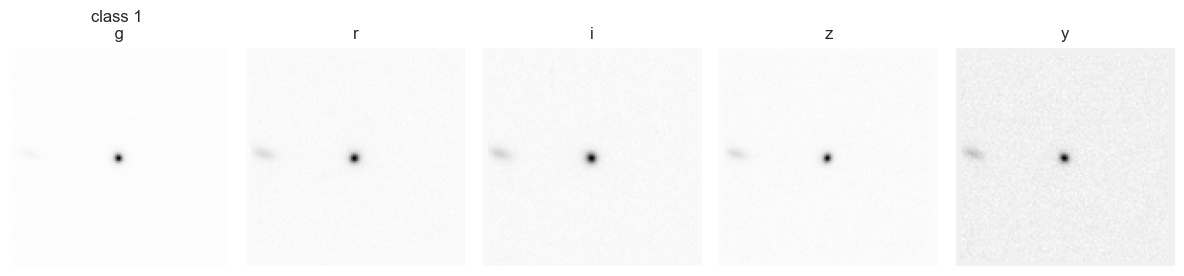

In [39]:
# Print some images from the training dataset to verify everything is working
print_image(0, dataset)

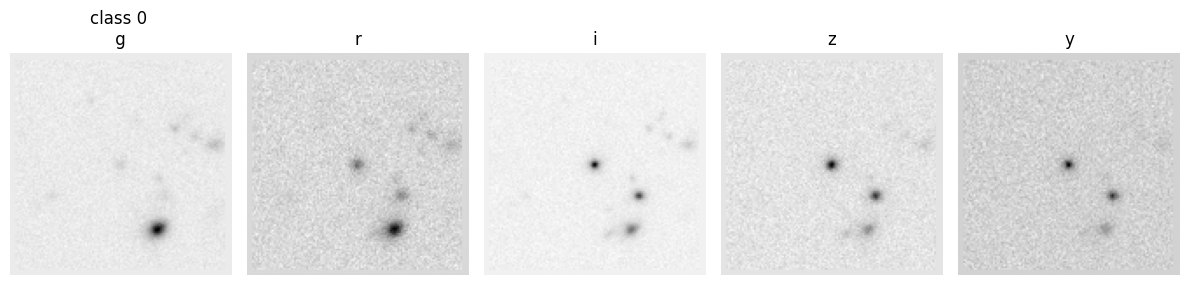

In [16]:
print_image(16_000, dataset)

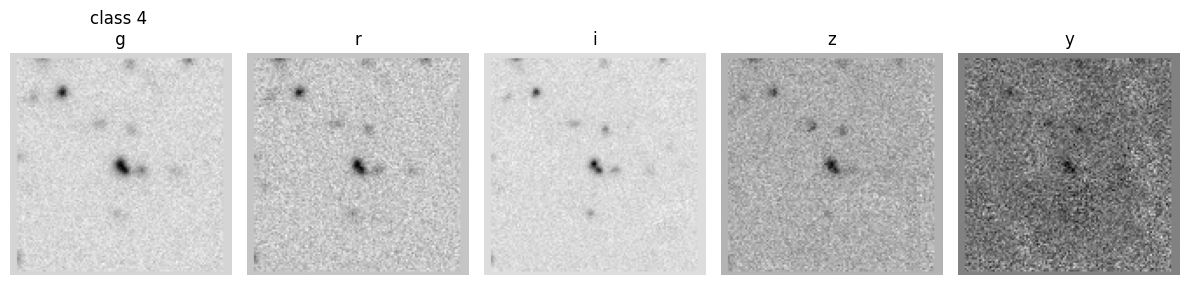

In [17]:
print_image(204_572, dataset)

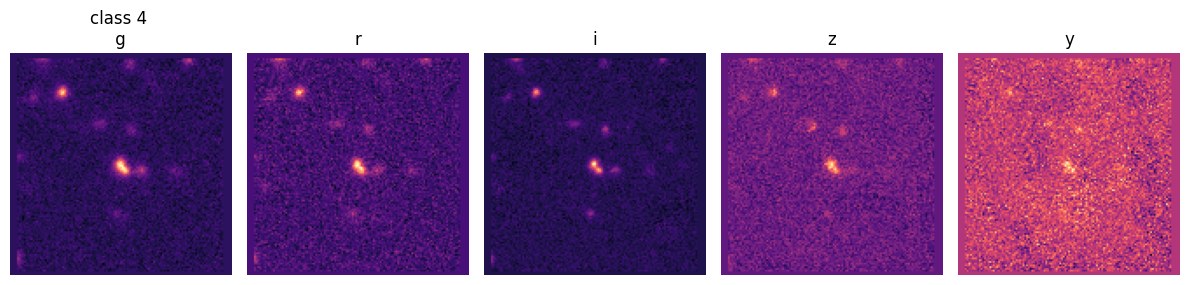

In [17]:
# Same images, but with the "magma" colormap to see if it reveals any different features than the default "gray_r" colormap
print_image(204_572, dataset, cmap="magma")

# Building and Training the CNN
## Adapting a CNN for 5 channels

Standard pre-trained CNNs expect 3 channels (RGB). GalaxyML data has 5 channels (u, g, r, i, z). We will modify a standard `ResNet18` to accept 5 channels

In [18]:
def get_galaxy_model():
    """
    Initializes a ResNet-18 model modified for our galaxy classification task.

    - The first convolutional layer is modified to accept 5 input channels (for the 5 photometric bands) 
    instead of the standard 3 (RGB).

    - The final fully connected layer is modified to output the number of classes we have defined for our 
    classification task (e.g., 5 classes for: 
        LTG / Disk, 
        Pseudobulge / Transition, 
        ETG / Classical Bulge, 
        Giant Elliptical / BCG, 
        Irregulars
    ).
    """
    
    # Start with an untrained ResNet-18 model
    model = models.resnet18(weights=None)  
    
    # Modify the first convolutional layer to accept 5 input channels instead of 3
    model.conv1 = nn.Conv2d(
        in_channels=5, 
        out_channels=64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Modify the final fully connected layer to output the number of classes
    num_classes = 5 
    model.fc = nn.Linear(
        in_features=model.fc.in_features, 
        out_features=num_classes
    )
    
    return model

In [19]:
# Sample to check the model architecture and output shape
model = get_galaxy_model()
sample_input = torch.randn(2, 5, 127, 127)  # Batch size of 2, 5 channels, 127x127 image
output = model(sample_input)
print("Output shape:", output.shape)  # Should be (2, num_classes)

Output shape: torch.Size([2, 5])


In [20]:
# Check the lengths of the created label and index numpy files to ensure they match and are correct
print(len(np.load("train_labels.npy")))
print(len(np.load("train_indices.npy")))

204573
204573


In [21]:
# Train the model
# remember we defined loader as the DataLoader for our training dataset, so we can use that to get batches of data for training the model.
model = get_galaxy_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
input_images, labels = next(iter(loader))
print("Input images shape:", input_images.shape)  # Should be (batch_size, 5, 127, 127)
print("Labels shape:", labels.shape)  # Should be (batch_size,)

Input images shape: torch.Size([32, 5, 127, 127])
Labels shape: torch.Size([32])


### One batch smoke test to ensure the model can process the data without errors

In [22]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps") if torch.backends.mps.is_available() else device
model = get_galaxy_model().to(device)

model.train()
input_images, labels = next(iter(loader))
input_images = input_images.to(device)
labels = labels.to(device)

optimizer.zero_grad()
logits = model(input_images)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

preds = logits.argmax(dim=1)
acc = (preds == labels).float().mean().item()

print("One-batch loss:", float(loss.item()))
print("One-batch acc:", acc)

One-batch loss: 1.579712152481079
One-batch acc: 0.21875


### Training Loop

In [ ]:
num_epochs = 5
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = get_galaxy_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for input_images, labels in loader:
        input_images = input_images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    print(f"Epoch {epoch+1}/{num_epochs} | loss={epoch_loss:.4f} | acc={epoch_acc:.4f}")

#### Training CNN results 13JUN. Time: 38m 24.8s
```
Epoch 1/5 | loss=0.4777 | acc=0.8082 
Epoch 2/5 | loss=0.3367 | acc=0.8634
Epoch 3/5 | loss=0.2869 | acc=0.8833
Epoch 4/5 | loss=0.2585 | acc=0.8952
Epoch 5/5 | loss=0.2382 | acc=0.9030
```

### Next Steps: CNN tuning:
At least explore learning rate, weight decay, batch size, epochs, and optionally dropout/data augmentation.
Use validation macro F1 for early stopping/model choice.

In [ ]:
# Reusable CNN training + experiment logging utility for hyperparameter tuning
import copy
import random
from datetime import datetime
from pathlib import Path
from sklearn.metrics import f1_score, recall_score

# Updated seed helper for Apple Silicon (MPS) + cross-device reproducibility
# Run this once before calling train_and_log_cnn(...)
def _set_seed(seed=42, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Newer PyTorch versions may expose an explicit MPS seed API.
    if torch.backends.mps.is_available() and hasattr(torch, "mps") and hasattr(torch.mps, "manual_seed"):
        torch.mps.manual_seed(seed)

    if deterministic:
        # Helps reproducibility; warn_only avoids hard failures on unsupported ops.
        torch.use_deterministic_algorithms(True, warn_only=True)

print("Updated _set_seed loaded (MPS-aware).")


def _make_run_id(params):
    t = datetime.now().strftime("%Y%m%d-%H%M%S")
    return f"{t}_lr{params['lr']}_bs{params['batch_size']}_wd{params['weight_decay']}"


def _append_run_summary(summary_row, runs_csv):
    row_df = pd.DataFrame([summary_row])
    if runs_csv.exists():
        old = pd.read_csv(runs_csv)
        out = pd.concat([old, row_df], ignore_index=True)
    else:
        out = row_df
    out.to_csv(runs_csv, index=False)
    return out


def train_and_log_cnn(
    params,
    train_dataset,
    val_dataset,
    model_fn=get_galaxy_model,
    num_classes=5,
    run_name=None,
):
    """Train one CNN configuration and log artifacts + summary row.

    Required params keys: lr, batch_size, weight_decay, epochs
    Optional params keys: optimizer (adam|adamw|sgd), seed, patience, notes
    """
    required = ["lr", "batch_size", "weight_decay", "epochs"]
    missing = [k for k in required if k not in params]
    if missing:
        raise KeyError(f"Missing required params keys: {missing}")

    seed = int(params.get("seed", 42))
    _set_seed(seed)

    runs_csv = Path(params.get("runs_csv", "cnn_tuning_runs.csv"))
    models_dir = Path(params.get("models_dir", "models"))
    metrics_dir = Path(params.get("metrics_dir", "metrics"))
    models_dir.mkdir(exist_ok=True)
    metrics_dir.mkdir(exist_ok=True)

    run_id = run_name if run_name else _make_run_id(params)

    local_device = torch.device("mps") if torch.backends.mps.is_available() else (
        torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=False,
    )

    model = model_fn().to(local_device)
    criterion = nn.CrossEntropyLoss()

    optimizer_name = str(params.get("optimizer", "adam")).lower()
    lr = float(params["lr"])
    weight_decay = float(params["weight_decay"])

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer must be one of: adam, adamw, sgd")

    epochs = int(params["epochs"])
    patience = int(params.get("patience", 3))

    history_rows = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_epoch = -1
    best_val_macro_f1 = -1.0
    best_wait = 0
    best_val_y_true = []
    best_val_y_pred = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for input_images, labels in train_loader:
            input_images = input_images.to(local_device)
            labels = labels.to(local_device)

            optimizer.zero_grad()
            logits = model(input_images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss_sum / max(train_total, 1)
        train_acc = train_correct / max(train_total, 1)

        model.eval()
        val_loss_sum = 0.0
        val_total = 0
        val_correct = 0
        y_true = []
        y_pred = []

        with torch.no_grad():
            for input_images, labels in val_loader:
                input_images = input_images.to(local_device)
                labels = labels.to(local_device)

                logits = model(input_images)
                loss = criterion(logits, labels)

                val_loss_sum += loss.item() * labels.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss = val_loss_sum / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        val_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        val_weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_macro_f1": val_macro_f1,
                "val_weighted_f1": val_weighted_f1,
            }
        )

        print(
            f"[{run_id}] epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            best_val_y_true = y_true
            best_val_y_pred = y_pred
            best_wait = 0
        else:
            best_wait += 1
            if best_wait >= patience:
                print(f"[{run_id}] early stopping at epoch {epoch} (patience={patience})")
                break

    history_df = pd.DataFrame(history_rows)

    history_path = metrics_dir / f"{run_id}_history.csv"
    history_df.to_csv(history_path, index=False)

    model_path = models_dir / f"{run_id}.pt"
    torch.save(best_state_dict, model_path)

    recalls = recall_score(
        best_val_y_true,
        best_val_y_pred,
        labels=list(range(num_classes)),
        average=None,
        zero_division=0,
    )
    minority_recall = float(np.min(recalls)) if len(recalls) > 0 else 0.0

    final_train_acc = float(history_df.iloc[-1]["train_acc"])
    final_val_acc = float(history_df.iloc[-1]["val_acc"])
    best_row = history_df.loc[history_df["epoch"] == best_epoch].iloc[0]

    summary_row = {
        "run_id": run_id,
        "lr": lr,
        "batch_size": int(params["batch_size"]),
        "weight_decay": weight_decay,
        "optimizer": optimizer_name,
        "epochs": epochs,
        "patience": patience,
        "seed": seed,
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_row["val_loss"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_val_weighted_f1": float(best_row["val_weighted_f1"]),
        "final_train_acc": final_train_acc,
        "final_val_acc": final_val_acc,
        "minority_recall": minority_recall,
        "notes": params.get("notes", ""),
        "history_file": str(history_path),
        "model_file": str(model_path),
    }

    leaderboard = _append_run_summary(summary_row, runs_csv)
    print(f"[{run_id}] saved model -> {model_path}")
    print(f"[{run_id}] saved history -> {history_path}")
    print(f"[{run_id}] updated summary -> {runs_csv}")

    return {
        "run_id": run_id,
        "summary": summary_row,
        "history": history_df,
        "leaderboard": leaderboard,
        "best_state_dict": best_state_dict,
    }


# Example usage (run this after val_dataset has been created):
# params = {
#     "lr": 1e-3,
#     "batch_size": 32,
#     "weight_decay": 1e-4,
#     "epochs": 10,
#     "optimizer": "adamw",
#     "seed": 42,
#     "patience": 3,
#     "notes": "baseline tuning run",
# }
# result = train_and_log_cnn(params, train_dataset=dataset, val_dataset=val_dataset)
# pd.read_csv("cnn_tuning_runs.csv").sort_values(
#     ["best_val_macro_f1", "minority_recall"], ascending=False
# ).head(10)

In [23]:
# Get validation dataset and loader using the same function we used for training, 
# but with the validation HDF5 file and corresponding labels/indices numpy files

val_dataset, val_loader = make_dataset_and_loader(
    validation_hdf5,
    image_key="image",
    labels_npy_path="validation_labels.npy",
    indices_npy_path="validation_indices.npy",
    batch_size=32,
    shuffle=False
)

Total Images: 40914


In [31]:

params = {
    "lr": 1e-3,
    "batch_size": 32,
    "weight_decay": 1e-4,
    "epochs": 10,
    "optimizer": "adamw",
    "seed": 42,
    "patience": 3,
    "notes": "baseline tuning run",
}
result = train_and_log_cnn(params, train_dataset=dataset, val_dataset=val_dataset)
pd.read_csv("cnn_tuning_runs.csv").sort_values(
    ["best_val_macro_f1", "minority_recall"], ascending=False
).head(10)

[20260619-121030_lr0.001_bs32_wd0.0001] epoch 1/10 | train_loss=0.4804 train_acc=0.8065 | val_loss=0.3826 val_acc=0.8464 val_macro_f1=0.5908
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 2/10 | train_loss=0.3397 train_acc=0.8620 | val_loss=0.3163 val_acc=0.8670 val_macro_f1=0.7313
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 3/10 | train_loss=0.2891 train_acc=0.8825 | val_loss=0.2550 val_acc=0.8972 val_macro_f1=0.7634
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 4/10 | train_loss=0.2605 train_acc=0.8935 | val_loss=0.2498 val_acc=0.8973 val_macro_f1=0.7593
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 5/10 | train_loss=0.2394 train_acc=0.9034 | val_loss=0.2634 val_acc=0.8897 val_macro_f1=0.7725
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 6/10 | train_loss=0.2219 train_acc=0.9098 | val_loss=0.2434 val_acc=0.9005 val_macro_f1=0.7535
[20260619-121030_lr0.001_bs32_wd0.0001] epoch 7/10 | train_loss=0.2065 train_acc=0.9166 | val_loss=0.2586 val_acc=0.8928 val_macro_f1=0.7579
[20260619-121

,run_id,lr,batch_size,weight_decay,optimizer,epochs,patience,seed,best_epoch,best_val_loss,best_val_macro_f1,best_val_weighted_f1,final_train_acc,final_val_acc,minority_recall,notes,history_file,model_file
0,20260619-121030_lr0.001_bs32_wd0.0001,0.001,32,0.0001,adamw,10,3,42,5,0.263421,0.772542,0.891436,0.923612,0.892066,0.672783,baseline tuning run,metrics/20260619-121030_lr0.001_bs32_wd0.0001_...,models/20260619-121030_lr0.001_bs32_wd0.0001.pt


In [33]:
# Run a hyperparameter grid search using the train_and_log_cnn function and the train/validation 
# datasets we created for the training and validation splits. This will run multiple training runs 
# with different combinations of hyperparameters and log the results in a CSV file for comparison.

from itertools import product

# Define a hyperparameter grid to search over. I'm starting with a grid with 8 combos; I'm a bit
# concerned about the computation time, so hopefully 8 is a reasonable number of runs to start with, 
# but we can expand this grid as needed to explore more hyperparameter combinations.

 
grid = {
    "lr": [1e-3, 3e-4],          # 2
    "batch_size": [32, 64],      # 2
    "weight_decay": [1e-4],      # 1
    "optimizer": ["adamw"],      # 1
    "epochs": [12],              # 1
    "patience": [3, 5],          # 2
    "seed": [42],                # 1
}

keys = list(grid.keys())
values = [grid[k] for k in keys]
param_list = [dict(zip(keys, v)) for v in product(*values)]

for i, p in enumerate(param_list, 1):
    p["notes"] = f"grid_run_{i}"
    print(i, p)

1 {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 3, 'seed': 42, 'notes': 'grid_run_1'}
2 {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 5, 'seed': 42, 'notes': 'grid_run_2'}
3 {'lr': 0.001, 'batch_size': 64, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 3, 'seed': 42, 'notes': 'grid_run_3'}
4 {'lr': 0.001, 'batch_size': 64, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 5, 'seed': 42, 'notes': 'grid_run_4'}
5 {'lr': 0.0003, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 3, 'seed': 42, 'notes': 'grid_run_5'}
6 {'lr': 0.0003, 'batch_size': 32, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 5, 'seed': 42, 'notes': 'grid_run_6'}
7 {'lr': 0.0003, 'batch_size': 64, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'epochs': 12, 'patience': 3, 'seed': 42, 'notes': 'gr

In [34]:
all_results = []
for p in param_list:
    out = train_and_log_cnn(p, train_dataset=dataset, val_dataset=val_dataset)
    all_results.append(out["summary"])

leaderboard = pd.read_csv("cnn_tuning_runs.csv").sort_values(
    ["best_val_macro_f1", "minority_recall"],
    ascending=False
)
leaderboard.head(10)

[20260619-134924_lr0.001_bs32_wd0.0001] epoch 1/12 | train_loss=0.4804 train_acc=0.8065 | val_loss=0.3826 val_acc=0.8464 val_macro_f1=0.5908
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 2/12 | train_loss=0.3397 train_acc=0.8620 | val_loss=0.3163 val_acc=0.8670 val_macro_f1=0.7313
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 3/12 | train_loss=0.2891 train_acc=0.8825 | val_loss=0.2550 val_acc=0.8972 val_macro_f1=0.7634
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 4/12 | train_loss=0.2605 train_acc=0.8935 | val_loss=0.2498 val_acc=0.8973 val_macro_f1=0.7593
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 5/12 | train_loss=0.2394 train_acc=0.9034 | val_loss=0.2634 val_acc=0.8897 val_macro_f1=0.7725
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 6/12 | train_loss=0.2219 train_acc=0.9098 | val_loss=0.2434 val_acc=0.9005 val_macro_f1=0.7535
[20260619-134924_lr0.001_bs32_wd0.0001] epoch 7/12 | train_loss=0.2065 train_acc=0.9166 | val_loss=0.2586 val_acc=0.8928 val_macro_f1=0.7579
[20260619-134

,run_id,lr,batch_size,weight_decay,optimizer,epochs,patience,seed,best_epoch,best_val_loss,best_val_macro_f1,best_val_weighted_f1,final_train_acc,final_val_acc,minority_recall,notes,history_file,model_file
2,20260619-145503_lr0.001_bs32_wd0.0001,0.0010,32,0.0001,adamw,12,5,42,9,0.243026,0.792129,0.904468,0.957580,0.897321,0.610169,grid_run_2,metrics/20260619-145503_lr0.001_bs32_wd0.0001_...,models/20260619-145503_lr0.001_bs32_wd0.0001.pt
6,20260619-202717_lr0.0003_bs32_wd0.0001,0.0003,32,0.0001,adamw,12,5,42,10,0.270621,0.788131,0.896905,0.957810,0.889524,0.612288,grid_run_6,metrics/20260619-202717_lr0.0003_bs32_wd0.0001...,models/20260619-202717_lr0.0003_bs32_wd0.0001.pt
3,20260619-163345_lr0.001_bs64_wd0.0001,0.0010,64,0.0001,adamw,12,3,42,10,0.255906,0.781146,0.900027,0.950331,0.900279,0.632008,grid_run_3,metrics/20260619-163345_lr0.001_bs64_wd0.0001_...,models/20260619-163345_lr0.001_bs64_wd0.0001.pt
4,20260619-180547_lr0.001_bs64_wd0.0001,0.0010,64,0.0001,adamw,12,5,42,10,0.255906,0.781146,0.900027,0.950331,0.900279,0.632008,grid_run_4,metrics/20260619-180547_lr0.001_bs64_wd0.0001_...,models/20260619-180547_lr0.001_bs64_wd0.0001.pt
7,20260619-220613_lr0.0003_bs64_wd0.0001,0.0003,64,0.0001,adamw,12,3,42,9,0.258703,0.780274,0.901356,0.954676,0.896564,0.576271,grid_run_7,metrics/20260619-220613_lr0.0003_bs64_wd0.0001...,models/20260619-220613_lr0.0003_bs64_wd0.0001.pt
8,20260619-233839_lr0.0003_bs64_wd0.0001,0.0003,64,0.0001,adamw,12,5,42,9,0.258703,0.780274,0.901356,0.954676,0.896564,0.576271,grid_run_8,metrics/20260619-233839_lr0.0003_bs64_wd0.0001...,models/20260619-233839_lr0.0003_bs64_wd0.0001.pt
0,20260619-121030_lr0.001_bs32_wd0.0001,0.0010,32,0.0001,adamw,10,3,42,5,0.263421,0.772542,0.891436,0.923612,0.892066,0.672783,baseline tuning run,metrics/20260619-121030_lr0.001_bs32_wd0.0001_...,models/20260619-121030_lr0.001_bs32_wd0.0001.pt
1,20260619-134924_lr0.001_bs32_wd0.0001,0.0010,32,0.0001,adamw,12,3,42,5,0.263421,0.772542,0.891436,0.923612,0.892066,0.672783,grid_run_1,metrics/20260619-134924_lr0.001_bs32_wd0.0001_...,models/20260619-134924_lr0.001_bs32_wd0.0001.pt
5,20260619-193802_lr0.0003_bs32_wd0.0001,0.0003,32,0.0001,adamw,12,3,42,3,0.257062,0.766448,0.892612,0.911034,0.903994,0.586864,grid_run_5,metrics/20260619-193802_lr0.0003_bs32_wd0.0001...,models/20260619-193802_lr0.0003_bs32_wd0.0001.pt


In [41]:
leaderboard[["best_val_macro_f1", "minority_recall"]].head(1)

,best_val_macro_f1,minority_recall
2,0.792129,0.610169


In [44]:
best = leaderboard.iloc[0]
best_model_path = best["model_file"]
print(f"""Best Run: {best['run_id']} |
      val_macro_f1: {best['best_val_macro_f1']:.4f} |
      minority_recall: {best['minority_recall']:.4f} |
      model_file: {best_model_path}""")

Best Run: 20260619-145503_lr0.001_bs32_wd0.0001 |
      val_macro_f1: 0.7921 |
      minority_recall: 0.6102 |
      model_file: models/20260619-145503_lr0.001_bs32_wd0.0001.pt


In [45]:
model = get_galaxy_model()

In [49]:
# Keep model and input tensors on the same device for evaluation
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

state_dict = torch.load(best_model_path, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()
print(f"Evaluating on device: {device}")
print(f"Model parameter device: {next(model.parameters()).device}")

Evaluating on device: mps
Model parameter device: mps:0


In [20]:
test_dataset, test_loader = make_dataset_and_loader(
    test_hdf5,
    image_key="image",
    labels_npy_path="test_labels.npy",
    indices_npy_path="test_indices.npy",
    batch_size=32,
    shuffle=False
)

Total Images: 40914


In [51]:
# Evaluate the model
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    confusion_matrix)

def evaluate_model(model, loader, criterion, device):
    """Evaluates the model on the given DataLoader and computes various performance metrics.
    Args:        
        model: The trained PyTorch model to evaluate.
        loader: A DataLoader providing the evaluation dataset.
        criterion: The loss function used to compute the average loss.
        device: The device (CPU, GPU) on which to perform the evaluation.
    
    Returns: A dictionary containing the average loss, accuracy, F1 score, classification report, confusion matrix, and
             the true and predicted labels.
    
    """
    model.eval()
    total_loss = 0.0
    n = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_images, labels in loader:
            input_images = input_images.to(device)
            labels = labels.to(device)

            logits = model(input_images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(n, 1)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 Score: {macro_f1:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(conf_matrix)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1_score": macro_f1,
        "classification_report": report,
        "confusion_matrix": conf_matrix,
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds)
    }


In [50]:
# Validate the model using the validation DataLoader and compute performance metrics
print("Evaluating on validation set...")
val_results = evaluate_model(model, val_loader, criterion, device)


Evaluating on validation set...
Test Accuracy: 0.9046
Test F1 Score: 0.9045
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     11084
           1       0.94      0.94      0.94     24456
           2       0.86      0.81      0.83      3921
           3       0.71      0.61      0.66       472
           4       0.62      0.67      0.64       981

    accuracy                           0.90     40914
   macro avg       0.80      0.78      0.79     40914
weighted avg       0.90      0.90      0.90     40914

Confusion Matrix:
[[ 9884   840    14     3   343]
 [  981 23012   398    13    52]
 [   21   622  3168    98    12]
 [    4    63   115   288     2]
 [  269    44     7     1   660]]


In [52]:
# Evaluate the model on the test set using the test DataLoader and compute performance metrics
print("Evaluating on test set...")
test_results = evaluate_model(model, test_loader, criterion, device)

Evaluating on test set...
Test Accuracy: 0.9055
Test F1 Score: 0.9052
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     11069
           1       0.94      0.94      0.94     24465
           2       0.85      0.82      0.83      3906
           3       0.79      0.56      0.66       466
           4       0.62      0.68      0.65      1008

    accuracy                           0.91     40914
   macro avg       0.82      0.78      0.79     40914
weighted avg       0.91      0.91      0.91     40914

Confusion Matrix:
[[ 9885   823    14     4   343]
 [  974 23029   398     9    55]
 [   24   624  3189    55    14]
 [    4    61   136   263     2]
 [  267    56     2     0   683]]


## Supervised Evaluation - Step 1: Overall Results Reporting

### Metric Choice and Justification

We prioritize **Macro F1** as the primary model-selection metric because class frequencies are imbalanced and we want each class to contribute equally.

We also report:
- **Weighted F1** to reflect aggregate performance with class-frequency weighting.
- **Minority-class recall** (minimum per-class recall) to monitor failure on rare classes.
- **Accuracy** as a familiar secondary metric.

### Reporting Protocol

For tabular model-family comparisons (Logistic Regression vs Random Forest), we report **5-fold Stratified CV mean and standard deviation**. This avoids relying on a single split when comparing families.

CNN currently has a tuned holdout summary in this notebook. If needed for strict fold-to-fold family comparability, run a 5-fold CNN evaluation (higher compute).

In [11]:
# Compact supervised-model comparison table for the report
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import recall_score

# CNN row auto-populates from cnn_tuning_runs.csv; LR/RF rows auto-populate from tuning outputs.
# Embedding-model rows auto-populate from in-memory embedding evaluation variables when available.

def first_existing_path(*candidates):
    for p in candidates:
        if Path(p).exists():
            return p
    return candidates[0]

cnn_runs_path = first_existing_path(
    "cnn_tuning_runs.csv",
    "output-csv/cnn_results/cnn_tuning_runs.csv",
)
cnn_runs = pd.read_csv(cnn_runs_path)
cnn_best = cnn_runs.sort_values(
    ["best_val_macro_f1", "minority_recall"],
    ascending=False
).iloc[0]

cnn_hparams = {
    "lr": cnn_best["lr"],
    "batch_size": int(cnn_best["batch_size"]),
    "weight_decay": cnn_best["weight_decay"],
    "optimizer": cnn_best["optimizer"],
    "epochs": int(cnn_best["epochs"]),
    "patience": int(cnn_best["patience"]),
    "seed": int(cnn_best["seed"]),
}

# Pull LR results from in-memory tuning output if available; otherwise read saved CSV.
if "lr_tuning_summary" in globals():
    lr_best = {
        "best_hyperparameters": str(lr_tuning_summary["best_hyperparameters"]),
        "macro_f1": float(lr_tuning_summary["test_macro_f1"]),
        "weighted_f1": float(lr_tuning_summary["test_weighted_f1"]),
        "minority_recall": float(lr_tuning_summary["test_minority_recall"]),
        "notes": f"CV macro F1={lr_tuning_summary['cv_best_macro_f1']:.4f}",
    }
else:
    try:
        lr_saved_path = first_existing_path(
            "lr_tuning_summary.csv",
            "output-csv/lr results/lr_tuning_summary.csv",
        )
        lr_saved = pd.read_csv(lr_saved_path).iloc[0]
        lr_best = {
            "best_hyperparameters": str(lr_saved["best_hyperparameters"]),
            "macro_f1": float(lr_saved["test_macro_f1"]),
            "weighted_f1": float(lr_saved["test_weighted_f1"]),
            "minority_recall": float(lr_saved["test_minority_recall"]),
            "notes": f"CV macro F1={float(lr_saved['cv_best_macro_f1']):.4f}",
        }
    except Exception:
        lr_best = {
            "best_hyperparameters": "TBD (run LR tuning and/or save lr_tuning_summary.csv)",
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "minority_recall": np.nan,
            "notes": "Tabular baseline on photometric/morphology features",
        }

# Pull RF results from in-memory tuning output if available; otherwise read saved CSV.
if "rf_tuning_summary" in globals():
    rf_best = {
        "best_hyperparameters": str(rf_tuning_summary["best_hyperparameters"]),
        "macro_f1": float(rf_tuning_summary["test_macro_f1"]),
        "weighted_f1": float(rf_tuning_summary["test_weighted_f1"]),
        "minority_recall": float(rf_tuning_summary["test_minority_recall"]),
        "notes": f"CV macro F1={rf_tuning_summary['cv_best_macro_f1']:.4f}",
    }
else:
    try:
        rf_saved_path = first_existing_path(
            "rf_tuning_summary.csv",
            "output-csv/rf results/rf_tuning_summary.csv",
        )
        rf_saved = pd.read_csv(rf_saved_path).iloc[0]
        rf_best = {
            "best_hyperparameters": str(rf_saved["best_hyperparameters"]),
            "macro_f1": float(rf_saved["test_macro_f1"]),
            "weighted_f1": float(rf_saved["test_weighted_f1"]),
            "minority_recall": float(rf_saved["test_minority_recall"]),
            "notes": f"CV macro F1={float(rf_saved['cv_best_macro_f1']):.4f}",
        }
    except Exception:
        rf_best = {
            "best_hyperparameters": "TBD (run RF tuning and/or save rf_tuning_summary.csv)",
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "minority_recall": np.nan,
            "notes": "Tree ensemble on tabular features",
        }

comparison_rows = [
    {
        "Model": "CNN (ResNet18, 5-channel)",
        "Feature Representation": "5-band image tensor (g, r, i, z, y); spatial pixel structure",
        "Best Hyperparameters": str(cnn_hparams),
        "Macro F1": float(cnn_best["best_val_macro_f1"]),
        "Weighted F1": float(cnn_best["best_val_weighted_f1"]),
        "Minority-Class Recall": float(cnn_best["minority_recall"]),
        "Notes": f"Best run: {cnn_best['run_id']} | {cnn_best.get('notes', '')}",
    },
    {
        "Model": "Logistic Regression",
        "Feature Representation": "Tabular photometric/morphology summary features",
        "Best Hyperparameters": lr_best["best_hyperparameters"],
        "Macro F1": lr_best["macro_f1"],
        "Weighted F1": lr_best["weighted_f1"],
        "Minority-Class Recall": lr_best["minority_recall"],
        "Notes": lr_best["notes"],
    },
    {
        "Model": "Random Forest",
        "Feature Representation": "Tabular photometric/morphology summary features",
        "Best Hyperparameters": rf_best["best_hyperparameters"],
        "Macro F1": rf_best["macro_f1"],
        "Weighted F1": rf_best["weighted_f1"],
        "Minority-Class Recall": rf_best["minority_recall"],
        "Notes": rf_best["notes"],
    },
]

# Add LR-on-embeddings row when embedding evaluation variables are available
if {"macro_f1", "weighted_f1", "acc"}.issubset(globals()):
    lr_emb_min_recall = np.nan
    if {"y_eval_emb", "y_pred_emb"}.issubset(globals()):
        lr_emb_min_recall = float(
            np.min(recall_score(y_eval_emb, y_pred_emb, average=None, zero_division=0))
        )
    comparison_rows.append(
        {
            "Model": "Logistic Regression (CNN embeddings)",
            "Feature Representation": "Fixed CNN embedding vector",
            "Best Hyperparameters": "solver=saga, class_weight=balanced, max_iter=3000",
            "Macro F1": float(macro_f1),
            "Weighted F1": float(weighted_f1),
            "Minority-Class Recall": lr_emb_min_recall,
            "Notes": f"Embedding-space classifier ({globals().get('eval_name', 'eval split unknown')}); acc={float(acc):.4f}",
        }
    )

# Add RF-on-embeddings row when embedding evaluation variables are available
if {"macro_f1_rf", "weighted_f1_rf", "acc_rf"}.issubset(globals()):
    rf_emb_min_recall = np.nan
    if {"y_eval_emb", "y_pred_rf_emb"}.issubset(globals()):
        rf_emb_min_recall = float(
            np.min(recall_score(y_eval_emb, y_pred_rf_emb, average=None, zero_division=0))
        )
    comparison_rows.append(
        {
            "Model": "Random Forest (CNN embeddings)",
            "Feature Representation": "Fixed CNN embedding vector",
            "Best Hyperparameters": "n_estimators=500, class_weight=balanced_subsample, random_state=42",
            "Macro F1": float(macro_f1_rf),
            "Weighted F1": float(weighted_f1_rf),
            "Minority-Class Recall": rf_emb_min_recall,
            "Notes": f"Embedding-space classifier ({globals().get('eval_name', 'eval split unknown')}); acc={float(acc_rf):.4f}",
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,Model,Feature Representation,Best Hyperparameters,Macro F1,Weighted F1,Minority-Class Recall,Notes
0,"CNN (ResNet18, 5-channel)","5-band image tensor (g, r, i, z, y); spatial p...","{'lr': np.float64(0.001), 'batch_size': 32, 'w...",0.792129,0.904468,0.610169,Best run: 20260619-145503_lr0.001_bs32_wd0.000...
1,Logistic Regression,Tabular photometric/morphology summary features,TBD (run LR tuning and/or save lr_tuning_summa...,NaN,NaN,NaN,Tabular baseline on photometric/morphology fea...
2,Random Forest,Tabular photometric/morphology summary features,TBD (run RF tuning and/or save rf_tuning_summa...,NaN,NaN,NaN,Tree ensemble on tabular features
3,Logistic Regression (CNN embeddings),Fixed CNN embedding vector,"solver=saga, class_weight=balanced, max_iter=3000",0.744927,0.891064,0.821888,Embedding-space classifier (test); acc=0.8841
4,Random Forest (CNN embeddings),Fixed CNN embedding vector,"n_estimators=500, class_weight=balanced_subsam...",0.795933,0.910850,0.587983,Embedding-space classifier (test); acc=0.9120


In [12]:
comparison_table.to_csv("output-csv/comparison_table_full.csv", index=False)

In [27]:
# Step 1 code: 5-fold CV summary for best tabular models + family summary table
from sklearn.model_selection import cross_validate, StratifiedKFold

# Use a common feature set for tabular family comparison
cv_features = ["g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag"]
cv_features = [c for c in cv_features if c in labeled_images_df.columns]

cv_df = labeled_images_df[cv_features + ["galaxy_type"]].dropna()
X_cv = cv_df[cv_features]
y_cv = cv_df["galaxy_type"]

# Rebuild best LR estimator from saved tuning output
if "lr_tuning_summary" in globals():
    _lr_params = lr_tuning_summary["best_hyperparameters"]
else:
    _lr_params = pd.read_csv("lr_tuning_summary.csv").iloc[0]["best_hyperparameters"]

if isinstance(_lr_params, str):
    import ast
    _lr_params = ast.literal_eval(_lr_params)

lr_best_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            solver=_lr_params["model__solver"],
            penalty=_lr_params["model__penalty"],
            C=float(_lr_params["model__C"]),
            class_weight=_lr_params["model__class_weight"],
            max_iter=int(_lr_params["model__max_iter"]),
        ),
    ),
])

# Rebuild best RF estimator from saved tuning output
if "rf_tuning_summary" in globals():
    _rf_params = rf_tuning_summary["best_hyperparameters"]
else:
    _rf_params = pd.read_csv("rf_tuning_summary.csv").iloc[0]["best_hyperparameters"]

if isinstance(_rf_params, str):
    import ast
    _rf_params = ast.literal_eval(_rf_params)

rf_best_model_cv = RandomForestClassifier(
    n_estimators=int(_rf_params["n_estimators"]),
    max_depth=None if _rf_params["max_depth"] is None else int(_rf_params["max_depth"]),
    min_samples_leaf=int(_rf_params["min_samples_leaf"]),
    max_features=_rf_params["max_features"],
    class_weight=_rf_params["class_weight"],
    random_state=42,
    n_jobs=-1,
)

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0),
    "weighted_f1": make_scorer(f1_score, average="weighted", zero_division=0),
    "accuracy": "accuracy",
}

lr_cv_scores = cross_validate(
    lr_best_model,
    X_cv,
    y_cv,
    cv=cv_splitter,
    scoring=cv_scoring,
    n_jobs=-1,
)

rf_cv_scores = cross_validate(
    rf_best_model_cv,
    X_cv,
    y_cv,
    cv=cv_splitter,
    scoring=cv_scoring,
    n_jobs=-1,
)

def summarize_cv(scores, model_name):
    return {
        "Model": model_name,
        "Macro F1 (CV mean)": float(np.mean(scores["test_macro_f1"])),
        "Macro F1 (CV std)": float(np.std(scores["test_macro_f1"])),
        "Weighted F1 (CV mean)": float(np.mean(scores["test_weighted_f1"])),
        "Weighted F1 (CV std)": float(np.std(scores["test_weighted_f1"])),
        "Accuracy (CV mean)": float(np.mean(scores["test_accuracy"])),
        "Accuracy (CV std)": float(np.std(scores["test_accuracy"])),
    }

cv_family_summary = pd.DataFrame([
    summarize_cv(lr_cv_scores, "Logistic Regression"),
    summarize_cv(rf_cv_scores, "Random Forest"),
])

# Add CNN holdout row for context (not CV)
cnn_holdout_row = {
    "Model": "CNN (ResNet18, 5-channel)",
    "Macro F1 (CV mean)": float(cnn_best["best_val_macro_f1"]),
    "Macro F1 (CV std)": np.nan,
    "Weighted F1 (CV mean)": float(cnn_best["best_val_weighted_f1"]),
    "Weighted F1 (CV std)": np.nan,
    "Accuracy (CV mean)": float(cnn_best["final_val_acc"]) if "final_val_acc" in cnn_best.index else np.nan,
    "Accuracy (CV std)": np.nan,
}

overall_results_table = pd.concat(
    [cv_family_summary, pd.DataFrame([cnn_holdout_row])],
    ignore_index=True,
)

overall_results_table = overall_results_table.sort_values("Macro F1 (CV mean)", ascending=False)
overall_results_table

# Optional export for report
overall_results_table.to_csv("supervised_overall_results_summary.csv", index=False)
print("Saved overall summary -> supervised_overall_results_summary.csv")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Saved overall summary -> supervised_overall_results_summary.csv


## Supervised Evaluation - Step 2 to Step 4 (In-Depth)

### Protocol Update

For this rerun, Step 2 to Step 4 use the **Random Forest trained on CNN embeddings** as the primary supervised model.
This evaluates whether the embedding representation improves downstream classifier performance and class-level behavior.

### Step 2A: Embedding-Dimension Importance
We report both impurity-based importance and permutation importance for embedding dimensions (emb_0 ... emb_n).

### Step 2B: Sensitivity Analysis
We vary key RF hyperparameters around the embedding-based baseline to measure robustness of macro F1, weighted F1, and minority recall.

### Step 2C: Identify Tradeoffs
We compare CNN, Logistic Regression on CNN embeddings, and Random Forest on CNN embeddings using macro F1, weighted F1, and minority recall.

### Step 3: Failure Analysis
We extract at least 3 specific misclassified examples with different failure categories (true class vs predicted class).

In [27]:
# Step 2-4 code (embedding version): RF on CNN embeddings for sensitivity, tradeoffs, and failure analysis
from pathlib import Path
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score, recall_score, accuracy_score, classification_report

# ---------- Load embedding splits ----------
train_emb_path = "embeddings/train_cnn_embeddings.npy"
train_lbl_path = "embeddings/train_labels.npy"
val_emb_path = "embeddings/validation_cnn_embeddings.npy"
val_lbl_path = "embeddings/validation_labels.npy"
test_emb_path = "embeddings/test_cnn_embeddings.npy"
test_lbl_path = "embeddings/test_labels.npy"

X_train_eval = np.load(train_emb_path)
y_train_eval = np.load(train_lbl_path)

if Path(test_emb_path).exists() and Path(test_lbl_path).exists():
    X_test_eval = np.load(test_emb_path)
    y_test_eval = np.load(test_lbl_path)
    eval_split_name = "test"
else:
    X_test_eval = np.load(val_emb_path)
    y_test_eval = np.load(val_lbl_path)
    eval_split_name = "validation"

print(f"Embedding eval split: {eval_split_name}")
print(f"Train shape: {X_train_eval.shape} | Eval shape: {X_test_eval.shape}")

# ---------- Base RF-on-embeddings model ----------
if "rf_on_emb" in globals():
    rf_eval_model = rf_on_emb
else:
    rf_eval_model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    rf_eval_model.fit(X_train_eval, y_train_eval)

rf_eval_pred = rf_eval_model.predict(X_test_eval)

rf_eval_macro_f1 = f1_score(y_test_eval, rf_eval_pred, average="macro", zero_division=0)
rf_eval_weighted_f1 = f1_score(y_test_eval, rf_eval_pred, average="weighted", zero_division=0)
rf_eval_accuracy = accuracy_score(y_test_eval, rf_eval_pred)
rf_eval_per_class_recall = recall_score(
    y_test_eval,
    rf_eval_pred,
    labels=sorted(np.unique(y_test_eval)),
    average=None,
    zero_division=0,
    )
rf_eval_minority_recall = float(np.min(rf_eval_per_class_recall))

print("RF-on-embeddings holdout metrics")
print(f"Macro F1: {rf_eval_macro_f1:.4f}")
print(f"Weighted F1: {rf_eval_weighted_f1:.4f}")
print(f"Accuracy: {rf_eval_accuracy:.4f}")
print(f"Minority recall: {rf_eval_minority_recall:.4f}")

# ---------- Embedding-dimension importance ----------
embed_feature_names = [f"emb_{i}" for i in range(X_train_eval.shape[1])]
rf_embed_importance = pd.DataFrame({
    "feature": embed_feature_names,
    "gini_importance": rf_eval_model.feature_importances_,
}).sort_values("gini_importance", ascending=False)
rf_embed_importance.to_csv("rf_embedding_feature_importance.csv", index=False)

perm = permutation_importance(
    rf_eval_model,
    X_test_eval,
    y_test_eval,
    scoring=make_scorer(f1_score, average="macro", zero_division=0),
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    )

rf_perm_importance = pd.DataFrame({
    "feature": embed_feature_names,
    "perm_macro_f1_drop_mean": perm.importances_mean,
    "perm_macro_f1_drop_std": perm.importances_std,
}).sort_values("perm_macro_f1_drop_mean", ascending=False)
rf_perm_importance.to_csv("rf_embedding_permutation_importance.csv", index=False)

# ---------- Sensitivity Analysis ----------
sensitivity_grid = ParameterGrid({
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 20, 40],
    "min_samples_leaf": [1, 2],
})

sensitivity_rows = []
for hp in sensitivity_grid:
    model = RandomForestClassifier(
        n_estimators=hp["n_estimators"],
        max_depth=hp["max_depth"],
        min_samples_leaf=hp["min_samples_leaf"],
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_eval, y_train_eval)
    pred = model.predict(X_test_eval)

    macro = f1_score(y_test_eval, pred, average="macro", zero_division=0)
    weighted = f1_score(y_test_eval, pred, average="weighted", zero_division=0)
    recalls = recall_score(
        y_test_eval,
        pred,
        labels=sorted(np.unique(y_test_eval)),
        average=None,
        zero_division=0,
    )
    min_recall = float(np.min(recalls))

    sensitivity_rows.append({
        "n_estimators": hp["n_estimators"],
        "max_depth": hp["max_depth"],
        "min_samples_leaf": hp["min_samples_leaf"],
        "macro_f1": float(macro),
        "weighted_f1": float(weighted),
        "minority_recall": min_recall,
    })

rf_embedding_sensitivity_results = pd.DataFrame(sensitivity_rows).sort_values(
    ["macro_f1", "minority_recall"], ascending=False
    )
rf_embedding_sensitivity_results.to_csv("rf_embedding_sensitivity_results.csv", index=False)

# ---------- Tradeoff Summary ----------
cnn_minority = float(cnn_best["minority_recall"]) if "minority_recall" in cnn_best.index else np.nan
lr_emb_minority = np.nan
if {"y_eval_emb", "y_pred_emb"}.issubset(globals()):
    lr_emb_minority = float(
        np.min(
            recall_score(
                y_eval_emb,
                y_pred_emb,
                labels=sorted(np.unique(y_eval_emb)),
                average=None,
                zero_division=0,
            )
        )
    )

rf_emb_minority = float(
    np.min(
        recall_score(
            y_test_eval,
            rf_eval_pred,
            labels=sorted(np.unique(y_test_eval)),
            average=None,
            zero_division=0,
        )
    )
)

tradeoff_table = pd.DataFrame([
    {
        "Model": "CNN (ResNet18, 5-channel)",
        "Macro F1": float(cnn_best["best_val_macro_f1"]),
        "Weighted F1": float(cnn_best["best_val_weighted_f1"]),
        "Minority Recall": cnn_minority,
        "Evaluation Protocol": "Best CNN run (validation)",
    },
    {
        "Model": "Logistic Regression (CNN embeddings)",
        "Macro F1": float(macro_f1) if "macro_f1" in globals() else np.nan,
        "Weighted F1": float(weighted_f1) if "weighted_f1" in globals() else np.nan,
        "Minority Recall": lr_emb_minority,
        "Evaluation Protocol": f"Holdout on {eval_split_name} embeddings",
    },
    {
        "Model": "Random Forest (CNN embeddings)",
        "Macro F1": float(rf_eval_macro_f1),
        "Weighted F1": float(rf_eval_weighted_f1),
        "Minority Recall": float(rf_emb_minority),
        "Evaluation Protocol": f"Holdout on {eval_split_name} embeddings",
    },
])
tradeoff_table.to_csv("supervised_tradeoff_table_embeddings.csv", index=False)

# ---------- Failure Analysis (3 examples from different confusion categories when possible) ----------
failure_df = pd.DataFrame({
    "true_label": y_test_eval,
    "pred_label": rf_eval_pred,
})
failure_df = failure_df[failure_df["true_label"] != failure_df["pred_label"]].copy()
failure_df["failure_category"] = (
    "true_" + failure_df["true_label"].astype(str) + "_pred_" + failure_df["pred_label"].astype(str)
)

failure_examples = (
    failure_df.reset_index(names="sample_index")
    .groupby("failure_category", as_index=False)
    .head(1)
    .head(3)
)

if len(failure_examples) < 3:
    needed = 3 - len(failure_examples)
    pool = failure_df.reset_index(names="sample_index")
    top_up = pool.loc[~pool["sample_index"].isin(failure_examples["sample_index"])]
    failure_examples = pd.concat([failure_examples, top_up.head(needed)], ignore_index=True)

if "CLASS_NAMES" in globals():
    failure_examples["true_class_name"] = failure_examples["true_label"].map(CLASS_NAMES)
    failure_examples["pred_class_name"] = failure_examples["pred_label"].map(CLASS_NAMES)

failure_examples.to_csv("rf_embedding_failure_examples.csv", index=False)

print("\nSaved artifacts:")
print("- rf_embedding_feature_importance.csv")
print("- rf_embedding_permutation_importance.csv")
print("- rf_embedding_sensitivity_results.csv")
print("- supervised_tradeoff_table_embeddings.csv")
print("- rf_embedding_failure_examples.csv")

print("\nTop embedding dimensions (permutation importance):")
display(rf_perm_importance.head(15))

print("Sensitivity results (best first):")
display(rf_embedding_sensitivity_results.head(12))

print("Tradeoff summary table (embedding-based):")
display(tradeoff_table)

print("Failure examples (3 records):")
display(failure_examples)

print("\nClassification report (RF-on-embeddings):")
print(classification_report(y_test_eval, rf_eval_pred, zero_division=0))

Embedding eval split: test
Train shape: (204573, 512) | Eval shape: (40914, 512)
RF-on-embeddings holdout metrics
Macro F1: 0.7959
Weighted F1: 0.9109
Accuracy: 0.9120
Minority recall: 0.5880


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn


Saved artifacts:
- rf_embedding_feature_importance.csv
- rf_embedding_permutation_importance.csv
- rf_embedding_sensitivity_results.csv
- supervised_tradeoff_table_embeddings.csv
- rf_embedding_failure_examples.csv

Top embedding dimensions (permutation importance):


,feature,perm_macro_f1_drop_mean,perm_macro_f1_drop_std
501,emb_501,0.005199,0.000774
470,emb_470,0.004079,0.000730
360,emb_360,0.003788,0.000958
394,emb_394,0.002786,0.000591
271,emb_271,0.002506,0.001316
23,emb_23,0.002471,0.001266
508,emb_508,0.002431,0.001597
84,emb_84,0.002107,0.000510
275,emb_275,0.002053,0.001320
187,emb_187,0.002049,0.000177


Sensitivity results (best first):


...

Tradeoff summary table (embedding-based):


,Model,Macro F1,Weighted F1,Minority Recall,Evaluation Protocol
0,"CNN (ResNet18, 5-channel)",0.792129,0.904468,0.610169,Best CNN run (validation)
1,Logistic Regression (CNN embeddings),0.744927,0.891064,0.821888,Holdout on test embeddings
2,Random Forest (CNN embeddings),0.795933,0.910850,0.587983,Holdout on test embeddings


Failure examples (3 records):


,sample_index,true_label,pred_label,failure_category,true_class_name,pred_class_name
0,24,1,0,true_1_pred_0,Pseudobulge / Transition,LTG / Disk
2,35,2,1,true_2_pred_1,ETG / Classical Bulge,Pseudobulge / Transition
3,48,0,1,true_0_pred_1,LTG / Disk,Pseudobulge / Transition



Classification report (RF-on-embeddings):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     11069
           1       0.94      0.95      0.94     24465
           2       0.86      0.81      0.83      3906
           3       0.75      0.59      0.66       466
           4       0.70      0.60      0.64      1008

    accuracy                           0.91     40914
   macro avg       0.83      0.77      0.80     40914
weighted avg       0.91      0.91      0.91     40914



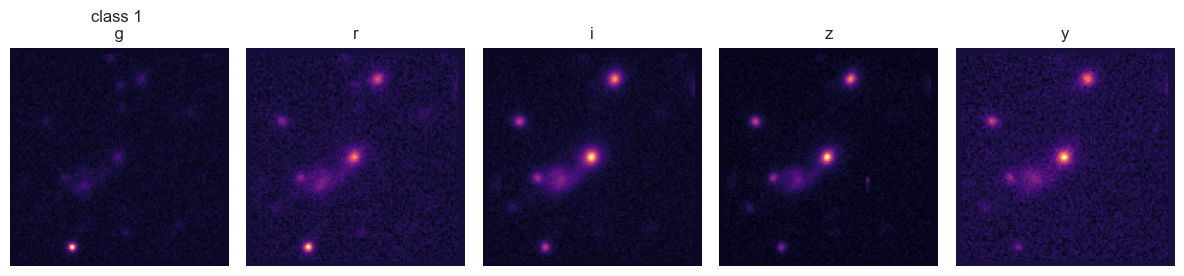

In [50]:
# image print of the three failure examples
print_image(24, dataset, cmap="magma")

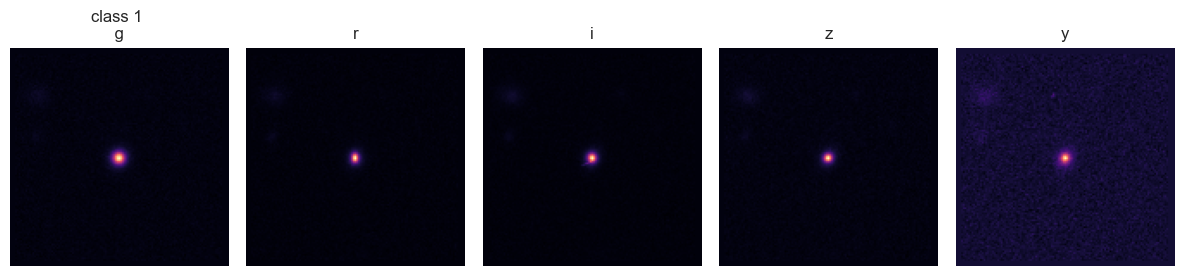

In [51]:
print_image(35, dataset, cmap="magma")

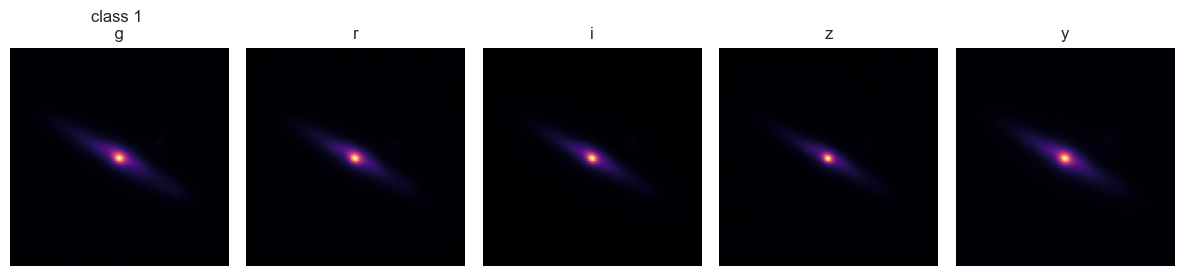

In [46]:
print_image(48, dataset, cmap="magma")

### CNN Cross-Validation Evaluation Plan (For Report)

To align model-family comparisons with the CV reporting requirement, evaluate the CNN with **stratified fold-based validation** using the same primary metric (**Macro F1**), plus **Weighted F1**, **accuracy**, and **minority-class recall**.

#### Full-Protocol Option (strictest)
- Use **5-fold Stratified CV** on the supervised dataset.
- For each fold:
  - Train CNN on the fold's training partition.
  - Use a validation split within that training partition for early stopping/model selection.
  - Evaluate once on the fold holdout partition.
- Aggregate fold results as **mean +/- std** for each metric.

#### Reduced-Compute Option (practical)
- Use **3-fold Stratified CV** with the same training recipe and metrics.
- Keep architecture, optimizer family, and early-stopping policy fixed from the tuned CNN setup.
- Report this explicitly as a computationally constrained variant and include fold-level mean +/- std.

#### Reproducibility Controls
- Fix seeds for Python/NumPy/PyTorch.
- Keep fold definitions deterministic (`random_state=42`).
- Keep epochs/patience and batch size constant across folds.

#### Reporting Sentence Template
"CNN was evaluated with stratified K-fold cross-validation (K=5; reduced-compute variant K=3) using Macro F1 as the primary metric. We report fold-wise mean and standard deviation for Macro F1, Weighted F1, accuracy, and minority-class recall for fair comparison with tabular baselines."

In [53]:
# CNN CV scaffold (wired): fold loop + aggregated metrics
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, recall_score, accuracy_score

# Choose 5 for full protocol or 3 for reduced-compute protocol
cnn_cv_k = 5


cnn_cv = StratifiedKFold(n_splits=cnn_cv_k, shuffle=True, random_state=42)

# Use the already-created CNN training dataset as the source for fold slicing.
if "dataset" not in globals():
    raise RuntimeError("`dataset` is not defined. Run the CNN dataset creation cell first.")

source_dataset = dataset

# Use labels aligned to source_dataset length for stratification.
if "final_labels" in globals():
    y_for_folds = pd.Series(final_labels).reset_index(drop=True)
elif "y_cv" in globals():
    y_for_folds = y_cv.reset_index(drop=True)
else:
    raise RuntimeError("No stratification labels found. Run labeling/supervised prep cells first.")

if len(y_for_folds) != len(source_dataset):
    raise ValueError(
        f"Fold labels length ({len(y_for_folds)}) does not match dataset length ({len(source_dataset)}). "
        "Ensure the labels used for folds align with the CNN dataset."
    )

# Fixed training recipe for fair fold-to-fold comparison
cnn_cv_params_base = {
    "lr": 1e-3,
    "batch_size": 32,
    "weight_decay": 1e-4,
    "epochs": 12,
    "optimizer": "adamw",
    "seed": 42,
    "patience": 3,
    "runs_csv": "cnn_cv_runs.csv",
    "models_dir": "models/cnn_cv",
    "metrics_dir": "metrics/cnn_cv",
}

if torch.backends.mps.is_available():
    local_device = torch.device("mps")
elif torch.cuda.is_available():
    local_device = torch.device("cuda")
else:
    local_device = torch.device("cpu")

cnn_cv_fold_rows = []

for fold_id, (train_idx, valid_idx) in enumerate(cnn_cv.split(np.zeros(len(y_for_folds)), y_for_folds), start=1):
    print(f"\n=== CNN CV Fold {fold_id}/{cnn_cv_k} ===")

    fold_train_dataset = Subset(source_dataset, train_idx.tolist())
    fold_val_dataset = Subset(source_dataset, valid_idx.tolist())

    fold_params = dict(cnn_cv_params_base)
    fold_params["notes"] = f"cnn_cv_fold_{fold_id}"

    fold_result = train_and_log_cnn(
        fold_params,
        train_dataset=fold_train_dataset,
        val_dataset=fold_val_dataset,
        run_name=f"cnn_cv_fold_{fold_id}",
    )

    # Evaluate the fold's best checkpoint on that fold holdout partition.
    fold_model = get_galaxy_model().to(local_device)
    fold_model.load_state_dict(fold_result["best_state_dict"])
    fold_model.eval()

    fold_loader = DataLoader(
        fold_val_dataset,
        batch_size=int(cnn_cv_params_base["batch_size"]),
        shuffle=False,
    )

    y_true_fold = []
    y_pred_fold = []
    with torch.no_grad():
        for input_images, labels in fold_loader:
            input_images = input_images.to(local_device)
            labels = labels.to(local_device)

            logits = fold_model(input_images)
            preds = logits.argmax(dim=1)

            y_true_fold.extend(labels.cpu().numpy())
            y_pred_fold.extend(preds.cpu().numpy())

    fold_macro_f1 = f1_score(y_true_fold, y_pred_fold, average="macro", zero_division=0)
    fold_weighted_f1 = f1_score(y_true_fold, y_pred_fold, average="weighted", zero_division=0)
    fold_accuracy = accuracy_score(y_true_fold, y_pred_fold)
    fold_recall_vec = recall_score(
        y_true_fold,
        y_pred_fold,
        average=None,
        labels=sorted(np.unique(y_true_fold)),
        zero_division=0,
    )
    fold_minority_recall = float(np.min(fold_recall_vec))

    cnn_cv_fold_rows.append({
        "fold": fold_id,
        "macro_f1": float(fold_macro_f1),
        "weighted_f1": float(fold_weighted_f1),
        "accuracy": float(fold_accuracy),
        "minority_recall": float(fold_minority_recall),
        "run_id": fold_result["run_id"],
    })

cnn_cv_fold_df = pd.DataFrame(cnn_cv_fold_rows)

cnn_cv_summary = {
    "k_folds": int(cnn_cv_k),
    "macro_f1_mean": float(cnn_cv_fold_df["macro_f1"].mean()),
    "macro_f1_std": float(cnn_cv_fold_df["macro_f1"].std()),
    "weighted_f1_mean": float(cnn_cv_fold_df["weighted_f1"].mean()),
    "weighted_f1_std": float(cnn_cv_fold_df["weighted_f1"].std()),
    "accuracy_mean": float(cnn_cv_fold_df["accuracy"].mean()),
    "accuracy_std": float(cnn_cv_fold_df["accuracy"].std()),
    "minority_recall_mean": float(cnn_cv_fold_df["minority_recall"].mean()),
    "minority_recall_std": float(cnn_cv_fold_df["minority_recall"].std()),
}

cnn_cv_fold_df

# Export report artifacts
cnn_cv_fold_df.to_csv("cnn_cv_fold_metrics.csv", index=False)
pd.DataFrame([cnn_cv_summary]).to_csv("cnn_cv_summary.csv", index=False)
print("Saved: cnn_cv_fold_metrics.csv, cnn_cv_summary.csv")
print("CNN CV summary:", cnn_cv_summary)


=== CNN CV Fold 1/5 ===
[cnn_cv_fold_1] epoch 1/12 | train_loss=0.5123 train_acc=0.7948 | val_loss=0.4301 val_acc=0.8309 val_macro_f1=0.5331
[cnn_cv_fold_1] epoch 2/12 | train_loss=0.3716 train_acc=0.8482 | val_loss=0.3816 val_acc=0.8363 val_macro_f1=0.6635
[cnn_cv_fold_1] epoch 3/12 | train_loss=0.3146 train_acc=0.8726 | val_loss=0.2893 val_acc=0.8868 val_macro_f1=0.7545
[cnn_cv_fold_1] epoch 4/12 | train_loss=0.2823 train_acc=0.8857 | val_loss=0.7224 val_acc=0.7219 val_macro_f1=0.4735
[cnn_cv_fold_1] epoch 5/12 | train_loss=0.2570 train_acc=0.8958 | val_loss=0.2506 val_acc=0.8967 val_macro_f1=0.7705
[cnn_cv_fold_1] epoch 6/12 | train_loss=0.2378 train_acc=0.9035 | val_loss=0.2575 val_acc=0.8942 val_macro_f1=0.7447
[cnn_cv_fold_1] epoch 7/12 | train_loss=0.2201 train_acc=0.9113 | val_loss=0.3048 val_acc=0.8748 val_macro_f1=0.7381
[cnn_cv_fold_1] epoch 8/12 | train_loss=0.2026 train_acc=0.9181 | val_loss=0.2352 val_acc=0.9053 val_macro_f1=0.7823
[cnn_cv_fold_1] epoch 9/12 | train_loss

## Logistic Regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Photometric features
# photometric filters
# features = [
#     'g_cmodel_mag',
#     'r_cmodel_mag',
#     'i_cmodel_mag',
#     'z_cmodel_mag',
#     'y_cmodel_mag'
# ]

features = [
    'g_ellipticity',
    'r_ellipticity',
    'i_ellipticity',
    'z_ellipticity',
    'y_ellipticity',
    'specz_redshift',
]
model_df = labeled_images_df[features + ['galaxy_type']].dropna()

X = model_df[features]
y = model_df['galaxy_type']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.21      0.27     11211
           1       0.65      0.10      0.18     24386
           2       0.16      0.63      0.25      3812
           3       0.01      0.15      0.02       480
           4       0.06      0.51      0.11      1026

    accuracy                           0.19     40915
   macro avg       0.25      0.32      0.17     40915
weighted avg       0.50      0.19      0.21     40915



Results from LR using photometric filters as the features. 

```
features = [
    'g_cmodel_mag',
    'r_cmodel_mag',
    'i_cmodel_mag',
    'z_cmodel_mag',
    'y_cmodel_mag'
]
```

             precision    recall  f1-score   support

           0       0.43      0.24      0.31     11211
           1       0.72      0.14      0.23     24386
           2       0.17      0.72      0.27      3812
           3       0.01      0.18      0.02       480
           4       0.10      0.72      0.17      1026

    accuracy                           0.23     40915
    macro avg       0.29      0.40      0.20     40915
    weighted avg       0.56      0.23      0.25     40915


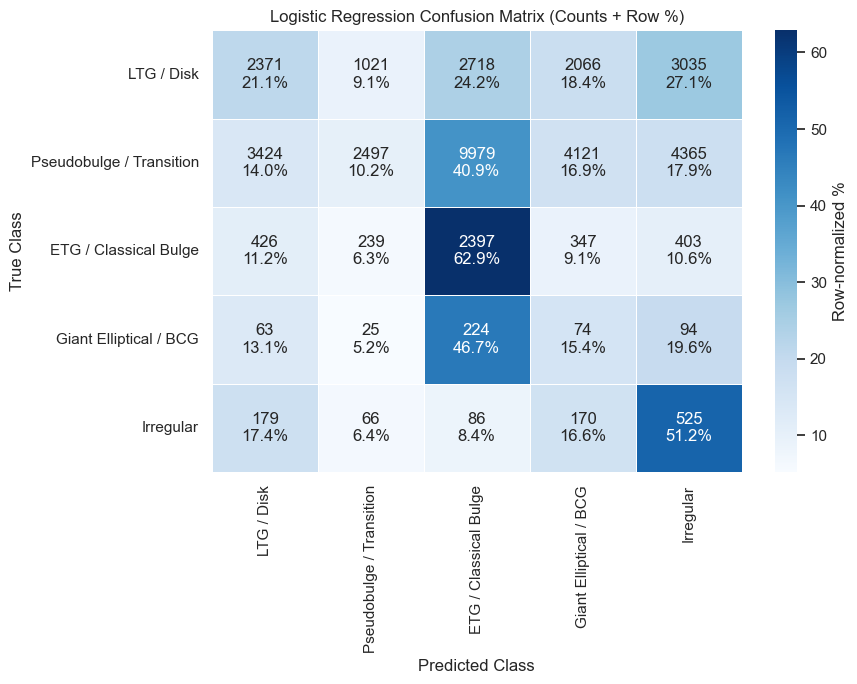

In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Requires predictions from the LR model cell above
if "y_test" not in globals() or "y_pred" not in globals():
    raise RuntimeError("Run the Logistic Regression prediction cell first to create y_test and y_pred.")

labels = sorted(np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred)])))
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_pct = confusion_matrix(y_test, y_pred, labels=labels, normalize="true") * 100

# Build readable class labels if CLASS_NAMES exists
if "CLASS_NAMES" in globals() and isinstance(CLASS_NAMES, dict):
    tick_labels = [CLASS_NAMES.get(int(c), str(c)) for c in labels]
else:
    tick_labels = [str(c) for c in labels]

annot = np.array([
    [f"{cm[r, c]}\n{cm_pct[r, c]:.1f}%" for c in range(cm.shape[1])]
    for r in range(cm.shape[0])
])

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Row-normalized %"},
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    linewidths=0.5,
    linecolor="white",
)
plt.title("Logistic Regression Confusion Matrix (Counts + Row %)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

### Next Steps: Logistic Regression tuning:
Grid over C, penalty, solver, class_weight.
Use StratifiedKFold CV with macro F1 scoring.

In [58]:
# Logistic Regression hyperparameter tuning (CV on train split)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

# Use separate grids so solver/penalty combinations stay valid.
# Copilot helped with this, but I also referred to the sklearn docs to ensure the combinations 
# of solver and penalty are valid.
lr_param_grid = [
    {
        "model__solver": ["lbfgs", "newton-cg", "saga"],
        "model__penalty": ["l2"],
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [2000],
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1"],
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [3000],
    },
]

lr_scoring = {
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0),
    "weighted_f1": make_scorer(f1_score, average="weighted", zero_division=0),
}

lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    scoring=lr_scoring,
    refit="macro_f1",
    cv=lr_cv,
    n_jobs=-1,
    verbose=1,
)

lr_grid.fit(X_train, y_train)

best_log_reg = lr_grid.best_estimator_
y_pred_lr_tuned = best_log_reg.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_lr_tuned, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test, y_pred_lr_tuned, average="weighted", zero_division=0)

# Minority-class recall: minimum recall across classes on the held-out test split.
class_labels = sorted(np.unique(y_test))
per_class_recall = recall_score(
    y_test,
    y_pred_lr_tuned,
    labels=class_labels,
    average=None,
    zero_division=0,
)
minority_recall = float(np.min(per_class_recall))

lr_tuning_summary = {
    "best_hyperparameters": lr_grid.best_params_,
    "cv_best_macro_f1": float(lr_grid.best_score_),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "test_minority_recall": minority_recall,
}

print("Best LR params:", lr_tuning_summary["best_hyperparameters"])
print(f"CV best macro F1: {lr_tuning_summary['cv_best_macro_f1']:.4f}")
print(f"Test macro F1: {lr_tuning_summary['test_macro_f1']:.4f}")
print(f"Test weighted F1: {lr_tuning_summary['test_weighted_f1']:.4f}")
print(f"Test minority-class recall: {lr_tuning_summary['test_minority_recall']:.4f}")
print("\nClassification report (tuned LR):")
print(classification_report(y_test, y_pred_lr_tuned, zero_division=0))

lr_cv_results = (
    pd.DataFrame(lr_grid.cv_results_)
    .sort_values("rank_test_macro_f1")
    [[
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "mean_test_weighted_f1",
        "param_model__solver",
        "param_model__penalty",
        "param_model__C",
        "param_model__class_weight",
    ]]
    .head(10)
)

lr_cv_results

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

Best LR params: {'model__C': 10.0, 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'l2', 'model__solver': 'newton-cg'}
CV best macro F1: 0.1770
Test macro F1: 0.1763
Test weighted F1: 0.4797
Test minority-class recall: 0.0000

Classification report (tuned LR):
              precision    recall  f1-score   support

           0       0.48      0.07      0.13     11211
           1       0.60      0.97      0.74     24386
           2       0.38      0.00      0.00      3812
           3       0.00      0.00      0.00       480
           4       0.27      0.00      0.01      1026

    accuracy                           0.60     40915
   macro avg       0.35      0.21      0.18     40915
weighted avg       0.53      0.60      0.48     40915



,rank_test_macro_f1,mean_test_macro_f1,mean_test_weighted_f1,param_model__solver,param_model__penalty,param_model__C,param_model__class_weight
13,1,0.176971,0.480959,newton-cg,l2,10.0,NaN
20,2,0.176970,0.480957,saga,l1,1.0,NaN
7,2,0.176970,0.480957,newton-cg,l2,1.0,NaN
22,4,0.176969,0.480955,saga,l1,10.0,NaN
8,5,0.176967,0.480950,saga,l2,1.0,NaN
0,6,0.176963,0.480939,lbfgs,l2,0.1,NaN
14,7,0.176960,0.480940,saga,l2,10.0,NaN
12,8,0.176959,0.480947,lbfgs,l2,10.0,NaN
6,9,0.176953,0.480930,lbfgs,l2,1.0,NaN
2,10,0.176940,0.480921,saga,l2,0.1,NaN


In [24]:
# Save Logistic Regression tuning summary to CSV for reporting/reproducibility
lr_summary_csv = "lr_tuning_summary.csv"
pd.DataFrame([lr_tuning_summary]).to_csv(lr_summary_csv, index=False)
print(f"Saved LR tuning summary -> {lr_summary_csv}")
pd.read_csv(lr_summary_csv)

Saved LR tuning summary -> lr_tuning_summary.csv


,best_hyperparameters,cv_best_macro_f1,test_macro_f1,test_weighted_f1,test_minority_recall
0,"{'model__C': 10.0, 'model__class_weight': None...",0.222245,0.224117,0.541315,0.0


## Random Forest

In [67]:
# Make copy of labeled dataframe
rf_train_df = labeled_images_df.copy()

feature_cols = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]

# Keep only features that actually exist in your dataframe
feature_cols = [c for c in feature_cols if c in rf_train_df.columns]

X = rf_train_df[feature_cols]
y = rf_train_df["galaxy_type"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts()


X shape: (204573, 5)
y shape: (204573,)


galaxy_type
1    97541
0    44846
2    15249
4     4104
3     1918
Name: count, dtype: int64

              precision    recall  f1-score   support

           0       0.54      0.51      0.53     11211
           1       0.79      0.39      0.52     24386
           2       0.18      0.59      0.28      3812
           3       0.03      0.08      0.04       480
           4       0.14      0.62      0.22      1026

    accuracy                           0.44     40915
   macro avg       0.34      0.44      0.32     40915
weighted avg       0.64      0.44      0.49     40915



<Figure size 600x500 with 0 Axes>

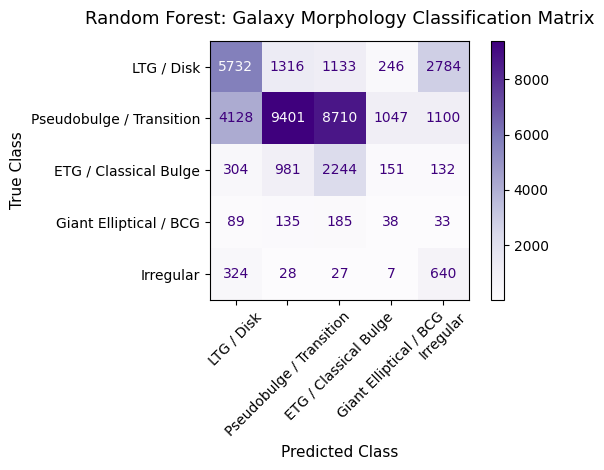

In [57]:
# Rannndom Forest Classifier 
# usefuk for feature importance and non-linear relationships, but can be prone to overfitting if not tuned properly.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
#Saving this for when we have 3 classes, but it would shown error right now because we only have 2 classes in our current dataset.
# Updated for the 5 classes

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, 
    display_labels=['LTG / Disk', 'Pseudobulge / Transition', 'ETG / Classical Bulge', 'Giant Elliptical / BCG', 'Irregular'] 
)


disp.plot(cmap='Purples', values_format='d')
plt.title("Random Forest: Galaxy Morphology Classification Matrix", fontsize=13, pad=12)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.xticks(rotation=45)
plt.grid(False) 
plt.tight_layout()
plt.show()


In [58]:
# Get taining and test accuracies
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")

Train accuracy: 0.480 | Test accuracy: 0.441


In [59]:
# Use class_weight='balanced_subsample' in the Random Forest to automatically adjust weights for each class based on their frequency in the training data, 
# which can help mitigate the effects of class imbalance and improve model performance on minority classes.

rf_boots = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf_boots.fit(X_train, y_train)

y_pred_rf_boots = rf_boots.predict(X_test)

print(classification_report(y_test, y_pred_rf_boots))

              precision    recall  f1-score   support

           0       0.54      0.51      0.52     11211
           1       0.79      0.39      0.52     24386
           2       0.18      0.59      0.28      3812
           3       0.03      0.08      0.04       480
           4       0.13      0.62      0.22      1026

    accuracy                           0.44     40915
   macro avg       0.33      0.44      0.32     40915
weighted avg       0.64      0.44      0.48     40915



### Next Steps: Random Forest tuning:
Grid over n_estimators, max_depth, min_samples_leaf, max_features, class_weight in [balanced, balanced_subsample].

In [25]:
# Random Forest hyperparameter tuning (CV on train split)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import make_scorer, f1_score, recall_score, classification_report

rf_features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
]
rf_features = [c for c in rf_features if c in labeled_images_df.columns]

rf_model_df = labeled_images_df[rf_features + ["galaxy_type"]].dropna()
rf_X = rf_model_df[rf_features]
rf_y = rf_model_df["galaxy_type"]

rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    rf_X,
    rf_y,
    test_size=0.2,
    random_state=42,
    stratify=rf_y,
)

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"],
}

rf_scoring = {
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0),
    "weighted_f1": make_scorer(f1_score, average="weighted", zero_division=0),
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring=rf_scoring,
    refit="macro_f1",
    cv=rf_cv,
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(rf_X_train, rf_y_train)

best_rf = rf_grid.best_estimator_
rf_y_pred_tuned = best_rf.predict(rf_X_test)

rf_test_macro_f1 = f1_score(rf_y_test, rf_y_pred_tuned, average="macro", zero_division=0)
rf_test_weighted_f1 = f1_score(rf_y_test, rf_y_pred_tuned, average="weighted", zero_division=0)

rf_class_labels = sorted(np.unique(rf_y_test))
rf_per_class_recall = recall_score(
    rf_y_test,
    rf_y_pred_tuned,
    labels=rf_class_labels,
    average=None,
    zero_division=0,
)
rf_minority_recall = float(np.min(rf_per_class_recall))

rf_tuning_summary = {
    "best_hyperparameters": rf_grid.best_params_,
    "cv_best_macro_f1": float(rf_grid.best_score_),
    "test_macro_f1": float(rf_test_macro_f1),
    "test_weighted_f1": float(rf_test_weighted_f1),
    "test_minority_recall": rf_minority_recall,
}

print("Best RF params:", rf_tuning_summary["best_hyperparameters"])
print(f"CV best macro F1: {rf_tuning_summary['cv_best_macro_f1']:.4f}")
print(f"Test macro F1: {rf_tuning_summary['test_macro_f1']:.4f}")
print(f"Test weighted F1: {rf_tuning_summary['test_weighted_f1']:.4f}")
print(f"Test minority-class recall: {rf_tuning_summary['test_minority_recall']:.4f}")
print("\nClassification report (tuned RF):")
print(classification_report(rf_y_test, rf_y_pred_tuned, zero_division=0))

rf_cv_results = (
    pd.DataFrame(rf_grid.cv_results_)
    .sort_values("rank_test_macro_f1")
    [[
        "rank_test_macro_f1",
        "mean_test_macro_f1",
        "mean_test_weighted_f1",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "param_max_features",
        "param_class_weight",
    ]]
    .head(10)
)

rf_summary_csv = "rf_tuning_summary.csv"
pd.DataFrame([rf_tuning_summary]).to_csv(rf_summary_csv, index=False)
print(f"\nSaved RF tuning summary -> {rf_summary_csv}")

rf_cv_results

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/V

Best RF params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
CV best macro F1: 0.3763
Test macro F1: 0.3702
Test weighted F1: 0.6088
Test minority-class recall: 0.0146

Classification report (tuned RF):
              precision    recall  f1-score   support

           0       0.58      0.67      0.62     11211
           1       0.77      0.61      0.68     24386
           2       0.23      0.39      0.29      3812
           3       0.06      0.01      0.02       480
           4       0.18      0.36      0.24      1026

    accuracy                           0.59     40915
   macro avg       0.36      0.41      0.37     40915
weighted avg       0.64      0.59      0.61     40915


Saved RF tuning summary -> rf_tuning_summary.csv


,rank_test_macro_f1,mean_test_macro_f1,mean_test_weighted_f1,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,param_class_weight
107,1,0.376348,0.614137,500,20,5,log2,balanced_subsample
98,1,0.376348,0.614137,500,20,5,sqrt,balanced_subsample
106,3,0.376309,0.613632,300,20,5,log2,balanced_subsample
97,3,0.376309,0.613632,300,20,5,sqrt,balanced_subsample
105,5,0.376091,0.613657,200,20,5,log2,balanced_subsample
96,5,0.376091,0.613657,200,20,5,sqrt,balanced_subsample
94,7,0.374772,0.624895,300,20,3,sqrt,balanced_subsample
103,7,0.374772,0.624895,300,20,3,log2,balanced_subsample
93,9,0.374715,0.624480,200,20,3,sqrt,balanced_subsample
102,9,0.374715,0.624480,200,20,3,log2,balanced_subsample


# JWST Dataset

In [53]:
# Image Samples
# This code is from the MultimodalUniverse Github repository, which is the source of our dataset. 
# It loads the dataset using Hugging Face's `datasets` library and retrieves an example to inspect its structure.
# Collab notebook: https://colab.research.google.com/github/MultimodalUniverse/MultimodalUniverse/blob/main/notebooks/getting_started.ipynb

dset_ls = load_dataset("MultimodalUniverse/jwst", 
                       streaming=True, 
                       split="train")
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

In [54]:
example = next(dset_iterator)
example.keys()

dict_keys(['image', 'mag_auto', 'flux_radius', 'flux_auto', 'fluxerr_auto', 'cxx_image', 'cyy_image', 'cxy_image', 'object_id'])

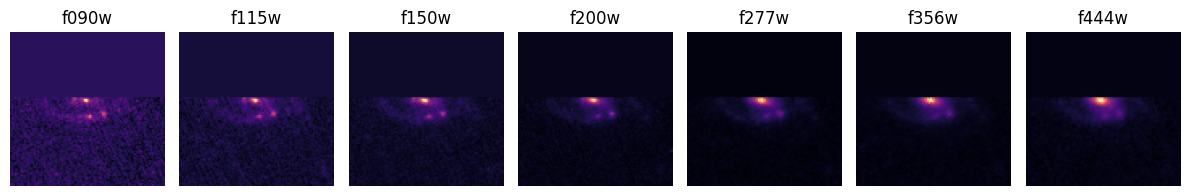

In [55]:
plt.figure(figsize=(12, 5))
n_bands = len(example["image"]["band"])
for i, b in enumerate(example["image"]["band"]):
    plt.subplot(1, n_bands, i + 1)
    plt.title(f"{b}")
    plt.imshow(example["image"]["flux"][i], cmap="magma")
    plt.axis("off")
plt.tight_layout()


Info about the photometric filters used in the JWST dataset: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-instrumentation/miri-filters-and-dispersers#gsc.tab=0

In [24]:
# Use the file grabber to get the JWST HDF5 files for training, validation, and testing datasets, 
# then inspect the keys in the HDF5 files to understand the structure of the data and how to access 
# the images and labels for training the model.

jwst_hdf5 = select_hdf5_file("Select JWST HDF5 file")
jwst_keys = inspect_hdf5_file(jwst_hdf5)

Selected file: /Volumes/NMELCHERT/MultimodelUniverse/jwst/primer-uds/healpix=1104/001-of-001.hdf5
Keys in the HDF5 file: ['a_image', 'apcorr_0', 'apcorr_1', 'apcorr_2', 'area_auto', 'area_iso', 'b_image', 'bkg_aper_0', 'bkg_aper_1', 'bkg_aper_2', 'bkg_auto', 'cflux', 'cpeak', 'cxx_image', 'cxy_image', 'cyy_image', 'dec', 'dummy_err', 'dummy_flux', 'errx2', 'errxy', 'erry2', 'f090w_bkg_aper_0', 'f090w_bkg_aper_1', 'f090w_bkg_aper_2', 'f090w_corr_0', 'f090w_corr_1', 'f090w_corr_2', 'f090w_ecorr_0', 'f090w_ecorr_1', 'f090w_ecorr_2', 'f090w_etot_0', 'f090w_etot_1', 'f090w_etot_2', 'f090w_flag_aper_0', 'f090w_flag_aper_1', 'f090w_flag_aper_2', 'f090w_flux_aper_0', 'f090w_flux_aper_1', 'f090w_flux_aper_2', 'f090w_fluxerr_aper_0', 'f090w_fluxerr_aper_1', 'f090w_fluxerr_aper_2', 'f090w_mask_aper_0', 'f090w_mask_aper_1', 'f090w_mask_aper_2', 'f090w_tot_0', 'f090w_tot_1', 'f090w_tot_2', 'f090w_tot_corr', 'f105w_bkg_aper_0', 'f105w_bkg_aper_1', 'f105w_bkg_aper_2', 'f105w_corr_0', 'f105w_corr_1', 

In [25]:
num_keys = len(jwst_keys)
print(f"Number of keys in the HDF5 file: {num_keys}")

Number of keys in the HDF5 file: 701


In [26]:
keys_with_image = [key for key in jwst_keys if "image" in key.lower()]
for k in keys_with_image:
    print(f"Key: {k}, shape: {h5py.File(jwst_hdf5, 'r')[k].shape}")
#print("Keys containing 'image':", keys_with_image)

Key: a_image, shape: (33021,)
Key: b_image, shape: (33021,)
Key: cxx_image, shape: (33021,)
Key: cxy_image, shape: (33021,)
Key: cyy_image, shape: (33021,)
Key: image_band, shape: (33021, 7)
Key: image_flux, shape: (33021, 7, 96, 96)
Key: image_ivar, shape: (33021, 7, 96, 96)
Key: image_mask, shape: (33021, 7, 96, 96)
Key: image_psf_fwhm, shape: (33021, 7)
Key: image_scale, shape: (33021, 7)
Key: theta_image, shape: (33021,)
Key: x2_image, shape: (33021,)
Key: x_image, shape: (33021,)
Key: xy_image, shape: (33021,)
Key: y2_image, shape: (33021,)
Key: y_image, shape: (33021,)


The keys with shapes that are (51058, 7, 96, 96) are likely the image data for the JWST dataset, where 51058 is the number of samples, 7 is the number of photometric bands, and 96x96 is the image size. Use the `image_flux` key to access the image data when creating your PyTorch Dataset for the JWST images. `image_ivar` and `image_mask` are for quality and image filtering.

In [27]:
jwst_dataset = GalaxyDataset(jwst_hdf5, image_key="image_flux")

# Find the 7 band names in the HDF5 file and print them out
with h5py.File(jwst_hdf5, "r") as f:
    band_names = f["image_band"][:1].astype(str)  # Convert bytes to strings
print("Band names in the JWST HDF5 file:", band_names)

Band names in the JWST HDF5 file: [['f090w' 'f115w' 'f150w' 'f200w' 'f277w' 'f356w' 'f444w']]


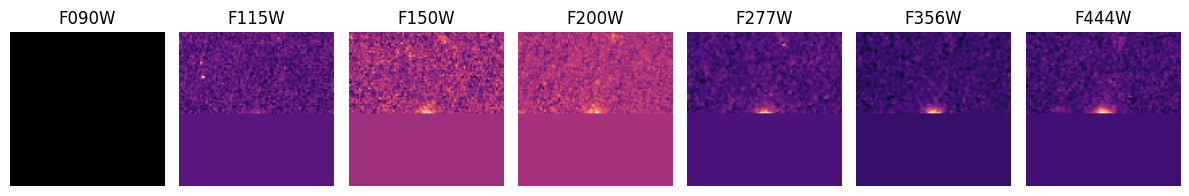

In [28]:
# Attempt to visualize a sample image from the JWST dataset to verify we can access the data correctly
print_image(0, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")


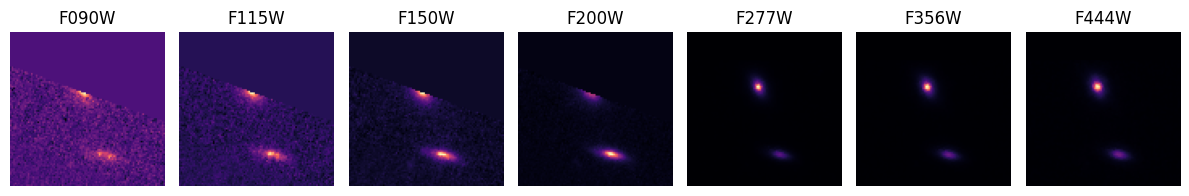

In [38]:
print_image(33_020, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")

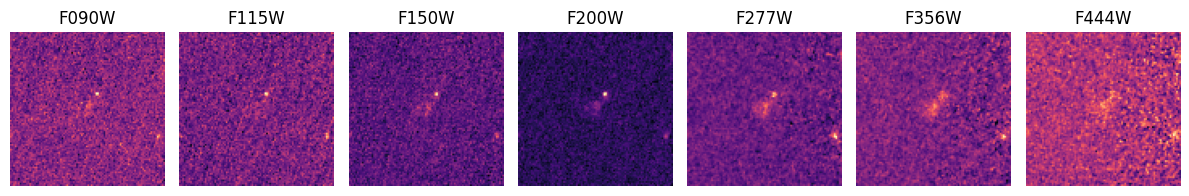

In [31]:
print_image(10_000, jwst_dataset, band_names=("F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"), cmap="magma")

There are no labels in the `jwst_dataset` to train a supervised model, but we can still visualize the images.
JWST data may be a good candidate for unsupervised learning.

In [46]:
# Unsupervised CNN for JWST (7-channel) using a convolutional autoencoder
from torch.utils.data import DataLoader, Dataset, Subset
from torch import nn, optim
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch.nn.functional as F
import pandas as pd
import numpy as np
import torch


class JWSTUnsupervisedDataset(Dataset):
    """Wraps jwst_dataset and optionally limits to a subset for faster experiments."""
    def __init__(self, base_dataset, max_samples=None):
        self.base = base_dataset
        n = len(base_dataset)
        self.indices = np.arange(n) if max_samples is None else np.arange(min(max_samples, n))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x = self.base[int(self.indices[idx])]
        if isinstance(x, (tuple, list)):
            x = x[0]
        x = torch.as_tensor(x, dtype=torch.float32)
        return x


class ConvAutoencoder7Ch(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(7, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, latent_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 7, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        # Ensure output spatial size exactly matches input (handles odd input sizes).
        x_hat = F.interpolate(x_hat, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return x_hat

    def encode(self, x):
        z = self.encoder(x)
        return z.mean(dim=(2, 3))  # global average pooling -> compact embedding


def train_autoencoder_unsupervised(
    model,
    dataloader,
    device,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-5,
    max_batches_per_epoch=None,
    clip_grad_norm=1.0,
    save_path="jwst_autoencoder_7ch.pt",
):
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.to(device)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch_idx, x in enumerate(dataloader):
            x = x.to(device)
            optimizer.zero_grad()
            x_hat = model(x)
            loss = criterion(x_hat, x)
            loss.backward()

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches += 1

            if max_batches_per_epoch is not None and n_batches >= max_batches_per_epoch:
                break

        mean_loss = epoch_loss / max(n_batches, 1)
        history.append({"epoch": epoch, "reconstruction_mse": mean_loss})
        print(f"Epoch {epoch}/{epochs} | reconstruction_mse={mean_loss:.6f}")

    torch.save(model.state_dict(), save_path)
    print(f"Saved model -> {save_path}")
    return pd.DataFrame(history)


@torch.no_grad()
def extract_embeddings(model, dataloader, device, max_batches=None):
    model.eval()
    model.to(device)
    all_emb = []

    for b_idx, x in enumerate(dataloader):
        x = x.to(device)
        emb = model.encode(x)
        all_emb.append(emb.cpu().numpy())
        if max_batches is not None and (b_idx + 1) >= max_batches:
            break

    if not all_emb:
        raise RuntimeError("No embeddings extracted. Check dataloader and max_batches.")
    return np.vstack(all_emb)


def cluster_embeddings(embeddings, k_values=range(2, 9), random_state=42):
    rows = []
    best_k = None
    best_score = -np.inf

    for k in k_values:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        rows.append({"k": k, "silhouette": float(score)})
        if score > best_score:
            best_score = score
            best_k = k

    scores_df = pd.DataFrame(rows).sort_values("k")
    best_kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=random_state)
    best_labels = best_kmeans.fit_predict(embeddings)

    return {
        "scores": scores_df,
        "best_k": int(best_k),
        "best_silhouette": float(best_score),
        "labels": best_labels,
        "kmeans": best_kmeans,
    }


## ---------- Example workflow ----------
## 1) Ensure jwst_dataset exists from prior JWST cells.
## 2) Start small, then scale up max_samples/epochs once it runs cleanly.

if "jwst_dataset" not in globals():
    raise RuntimeError("jwst_dataset not found. Run the JWST dataset-loading cells first.")

if torch.backends.mps.is_available():
    unsup_device = torch.device("mps")
elif torch.cuda.is_available():
    unsup_device = torch.device("cuda")
else:
    unsup_device = torch.device("cpu")

print(f"Using device for unsupervised JWST CNN: {unsup_device}")

# For first pass, keep this modest for runtime.
jwst_unsup_ds = JWSTUnsupervisedDataset(jwst_dataset, max_samples=None)
jwst_unsup_loader = DataLoader(jwst_unsup_ds, batch_size=64, shuffle=True)
jwst_embed_loader = DataLoader(jwst_unsup_ds, batch_size=128, shuffle=False)

ae7 = ConvAutoencoder7Ch(latent_channels=64)
ae_history = train_autoencoder_unsupervised(
    model=ae7,
    dataloader=jwst_unsup_loader,
    device=unsup_device,
    epochs=8,
    lr=1e-3,
    weight_decay=1e-5,
    max_batches_per_epoch=150,
    save_path="jwst_autoencoder_7ch.pt",
)

jwst_embeddings = extract_embeddings(
    model=ae7,
    dataloader=jwst_embed_loader,
    device=unsup_device,
)
print("Embeddings shape:", jwst_embeddings.shape)

cluster_out = cluster_embeddings(jwst_embeddings, k_values=range(2, 9), random_state=42)
print("Best k:", cluster_out["best_k"], "| silhouette:", round(cluster_out["best_silhouette"], 4))

cluster_scores = cluster_out["scores"]
jwst_cluster_labels = cluster_out["labels"]

cluster_scores.to_csv("jwst_unsup_cluster_scores.csv", index=False)
pd.DataFrame({
    "sample_idx": np.arange(len(jwst_cluster_labels)),
    "cluster": jwst_cluster_labels,
}).to_csv("jwst_unsup_cluster_labels.csv", index=False)
ae_history.to_csv("jwst_autoencoder_training_history.csv", index=False)

print("Saved: jwst_autoencoder_training_history.csv")
print("Saved: jwst_unsup_cluster_scores.csv")
print("Saved: jwst_unsup_cluster_labels.csv")
cluster_scores

Using device for unsupervised JWST CNN: mps
Epoch 1/8 | reconstruction_mse=15.147724
Epoch 2/8 | reconstruction_mse=10.003698
Epoch 3/8 | reconstruction_mse=9.948971
Epoch 4/8 | reconstruction_mse=4.669212
Epoch 5/8 | reconstruction_mse=6.742263
Epoch 6/8 | reconstruction_mse=6.423195
Epoch 7/8 | reconstruction_mse=9.478842
Epoch 8/8 | reconstruction_mse=4.465080
Saved model -> jwst_autoencoder_7ch.pt
Embeddings shape: (51058, 64)
Best k: 2 | silhouette: 0.9937
Saved: jwst_autoencoder_training_history.csv
Saved: jwst_unsup_cluster_scores.csv
Saved: jwst_unsup_cluster_labels.csv


,k,silhouette
0,2,0.993720
1,3,0.984062
2,4,0.982448
3,5,0.918882
4,6,0.918556
5,7,0.902310
6,8,0.893090


### Consider Feature Engineering and Selection for the final report. 
From report requirements:
>Feature engineering (6 points)

> Describe the steps you used to get from the raw input data to the final features used w/ supervised and unsupervised ML methods.

> Explain any initial preprocessing that was required to handle noisy or missing data.

> Be sure to include a complete list of all final features (in an appendix if necessary).


## Unsupervised ML Model

My idea rn is to cluster galaxies on their multi-band morphology/photometry profile and then use those clusters as a feature for classification, or to see if they correspond to known morphological classes.

In [72]:
rf_train_df.columns.tolist()

['coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 'skymap_id',
 '

In [73]:
# can move these to the top later
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
unsup_train_df = rf_train_df.copy()

#Not sure which features would be best for clustering, but I will start with the photometric magnitudes and some of the i-band morphology features
#  since those seem to be the most relevant to galaxy structure and redshift based on our earlier correlation analysis.
cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]

cluster_features = [c for c in cluster_features if c in unsup_train_df.columns]
 
cluster_df = unsup_train_df[cluster_features].dropna()
 
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)
 
# Pick k based on silhouette score 
# measures how similar an object is to its own cluster compared to other clusters, with higher scores indicating better-defined clusters.
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:", sil_scores)
print("Best k:", best_k)
 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df["morph_cluster"] = kmeans.fit_predict(X_cluster).astype(str)

First one used a sersic index, but that wouldn't make any sense since we would have to put it in as a feature

cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "g_sersic_index", "r_sersic_index", "i_sersic_index", "z_sersic_index", "y_sersic_index",
    "r_ellipticity", "i_half_light_radius"
]

Silhouette scores by k: {2: 0.2625173142663438, 3: 0.2638724791297067, 4: 0.26287306379101716, 5: 0.2555358072012217, 6: 0.19748655961165257, 7: 0.1874636529282637}
Best k: 3


cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]


Silhouette scores by k: {2: 0.2775704309367226, 3: 0.24920954920816976, 4: 0.24919139935657394, 5: 0.24031576973057436, 6: 0.20147958336445376, 7: 0.20055317360909672}
Best k: 2

###  Now that we have a model, I want to make the cluster a new feature to be used in the random forest model. May or may not be useful in predicting the galaxy class. 

In [142]:
model_df_with_cluster = unsup_train_df.merge(
    cluster_df[["morph_cluster"]],
    left_index=True, right_index=True, how="left"
)

In [143]:
model_df_with_cluster.head()

,image_idx,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,...,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,gz2class,separation,galaxy_type,morph_cluster
29783,29783,"b'(-204784.265625, 24080.68359375, -5356.69287...",-1.488138,1,1,1,17.735281,0.000706,0.472,14.519,...,15.135,7.995,-8.2591,5.28,-41.58,1.007,Sc?t,0.096143,2,1
29788,29788,"b'(-204671.875, 24544.234375, -7223.24072265625)'",-2.006866,1,1,1,17.208687,0.000557,0.471,12.845,...,12.136,6.760,-8.8767,5.94,-14.62,1.637,Sb2t,0.044243,1,2
29791,29791,"b'(-204676.09375, 24608.78515625, -6875.787109...",-1.910295,1,1,1,18.474453,0.001769,0.300,21.335,...,12.582,9.017,-7.4077,8.58,46.19,2.157,Sc?m,0.059871,1,1
29799,29799,"b'(-204731, 24402.173828125, -5909.5068359375)'",-1.641754,1,1,1,17.853600,0.000837,0.669,18.452,...,20.103,6.638,-7.4197,7.26,87.59,1.563,Sen,0.103360,1,1
29810,29810,"b'(-205254.5625, 18951.892578125, -7520.560546...",-2.089508,1,1,1,17.087647,0.000892,0.713,15.722,...,19.923,6.080,-8.9362,5.28,38.69,1.563,Ser,0.044021,2,2


In [ ]:
# since the cluster numbers are arbitrary, using the values of the cluster labels themselves is not meaningful for classification, 
# but they can still be used as categorical features to help the model learn patterns in the data.

# stuck here for now, but the idea is to use the cluster labels as additional features in the classification model, 
# which could potentially improve performance by providing a way for the model to learn from the underlying structure in the data

## Unsupervised Learning DCSCAN Model

In [116]:
#sample hdf5 file (can replace later)
jwst_hdf5 = "data/001-of-001.hdf5"
jwst_keys = inspect_hdf5_file(jwst_hdf5)

keys_with_image = [key for key in jwst_keys if "image" in key.lower()]
for k in keys_with_image:
    print(f"Key: {k}, shape: {h5py.File(jwst_hdf5, 'r')[k].shape}")

Selected file: data/001-of-001.hdf5
Keys in the HDF5 file: ['a_image', 'apcorr_0', 'apcorr_1', 'apcorr_2', 'area_auto', 'area_iso', 'b_image', 'bkg_aper_0', 'bkg_aper_1', 'bkg_aper_2', 'bkg_auto', 'cflux', 'cpeak', 'cxx_image', 'cxy_image', 'cyy_image', 'dec', 'dummy_err', 'dummy_flux', 'errx2', 'errxy', 'erry2', 'f105w_bkg_aper_0', 'f105w_bkg_aper_1', 'f105w_bkg_aper_2', 'f105w_corr_0', 'f105w_corr_1', 'f105w_corr_2', 'f105w_ecorr_0', 'f105w_ecorr_1', 'f105w_ecorr_2', 'f105w_etot_0', 'f105w_etot_1', 'f105w_etot_2', 'f105w_flag_aper_0', 'f105w_flag_aper_1', 'f105w_flag_aper_2', 'f105w_flux_aper_0', 'f105w_flux_aper_1', 'f105w_flux_aper_2', 'f105w_fluxerr_aper_0', 'f105w_fluxerr_aper_1', 'f105w_fluxerr_aper_2', 'f105w_mask_aper_0', 'f105w_mask_aper_1', 'f105w_mask_aper_2', 'f105w_tot_0', 'f105w_tot_1', 'f105w_tot_2', 'f105w_tot_corr', 'f115w_bkg_aper_0', 'f115w_bkg_aper_1', 'f115w_bkg_aper_2', 'f115w_corr_0', 'f115w_corr_1', 'f115w_corr_2', 'f115w_ecorr_0', 'f115w_ecorr_1', 'f115w_ecorr

In [117]:
#Create  dataframe for hdf5 file
with h5py.File(jwst_hdf5, "r") as f:
    jwst_df = pd.DataFrame({
        "a_image": np.array(f["a_image"][:], dtype=np.float64),
        "b_image": np.array(f["b_image"][:], dtype=np.float64),
        "theta_image": np.array(f["theta_image"][:], dtype=np.float64),
        "x_image": np.array(f["x_image"][:], dtype=np.float64),
        "y_image": np.array(f["y_image"][:], dtype=np.float64),
    })

jwst_df["ellipticity"] = 1 - (jwst_df["b_image"] / jwst_df["a_image"])

#brightness info
with h5py.File(jwst_hdf5, "r") as f:
    flux = f["image_flux"][:]

jwst_df["mean_flux"] = flux.mean(axis=(1,2,3))
jwst_df["std_flux"] = flux.std(axis=(1,2,3))
jwst_df["max_flux"] = flux.max(axis=(1,2,3))

jwst_df.head()

,a_image,b_image,theta_image,x_image,y_image,ellipticity,mean_flux,std_flux,max_flux
0,6.141305,2.635935,0.709554,2204.513622,1808.678233,0.570786,-0.000098,0.008441,0.194561
1,3.663806,2.683919,-0.325683,2212.070465,1820.861744,0.267450,-0.000164,0.008649,0.194561
2,1.975689,1.694170,-0.251685,2002.083184,1886.826405,0.142491,-0.000892,0.007070,0.201423
3,3.989676,3.829770,-1.479649,2367.835885,1911.086424,0.040080,0.001854,0.014869,0.416139
4,4.958206,4.344839,-1.487680,2474.581309,1918.039842,0.123708,0.005709,0.053210,2.383248


In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

feature_cols = [
    "a_image",
    "b_image",
    "ellipticity",
    "theta_image",
    "mean_flux",
    "std_flux",
    "max_flux"
]

# Make a clean numeric dataframe
X_df = (
    jwst_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Force native little-endian float64 buffer
X_np = X_df.to_numpy()
X_np = X_np.astype(np.float64, copy=True)
X_np = np.ascontiguousarray(X_np)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

dbscan = DBSCAN(
    eps=0.25,
    min_samples=30
)

clusters = dbscan.fit_predict(X_scaled)

jwst_df.loc[X_df.index, "cluster"] = clusters

print(pd.Series(clusters).value_counts().sort_index())

-1    2513
 0    2337
 1      29
 2      22
Name: count, dtype: int64


## CNN Embedding Extraction (Feature Extraction for Tabular Models)

This section uses your trained CNN as a fixed feature extractor.

Workflow:
1. Load or reuse the trained CNN.
2. Remove the final classification head to get embeddings.
3. Run train/validation/test loaders through the encoder.
4. Save embeddings and labels to disk.
5. (Optional) Train logistic regression on embeddings.

In [39]:
from pathlib import Path
import pandas as pd

def resolve_best_model_path(
    runs_csv="cnn_tuning_runs.csv",
    primary_metric="best_val_macro_f1",
    tie_break_metric="minority_recall",
):
    runs_path = Path(runs_csv)
    if not runs_path.exists():
        raise FileNotFoundError(f"Could not find {runs_csv}")

    df = pd.read_csv(runs_path)

    required_cols = [primary_metric, "model_file"]
    for c in required_cols:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    # Keep only rows where the checkpoint actually exists
    df["model_exists"] = df["model_file"].apply(lambda p: Path(str(p)).exists())
    df = df[df["model_exists"]].copy()
    if df.empty:
        raise FileNotFoundError("No existing checkpoint files found in model_file column.")

    sort_cols = [primary_metric]
    ascending = [False]

    if tie_break_metric in df.columns:
        sort_cols.append(tie_break_metric)
        ascending.append(False)

    best_row = df.sort_values(sort_cols, ascending=ascending).iloc[0]
    return str(best_row["model_file"]), best_row

best_model_path, best_row = resolve_best_model_path(
    runs_csv="output-csv/cnn_results/cnn_tuning_runs.csv",
    primary_metric="best_val_macro_f1",
    tie_break_metric="minority_recall",
)

print("Selected best checkpoint:", best_model_path)
print("Run ID:", best_row.get("run_id", "N/A"))

Selected best checkpoint: models/20260619-145503_lr0.001_bs32_wd0.0001.pt
Run ID: 20260619-145503_lr0.001_bs32_wd0.0001


In [40]:
# Extract fixed CNN embeddings from train/validation/test loaders
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path


def get_feature_extractor_from_resnet(model):
    """Return a feature extractor that outputs pooled backbone features (before final FC)."""
    # For ResNet, this keeps everything up to avgpool; output shape will be (N, 512, 1, 1)
    return nn.Sequential(*list(model.children())[:-1])


@torch.no_grad()
def extract_embeddings(loader, model, device, max_batches=None):
    """Extract embeddings and labels from a DataLoader.

    Returns
    -------
    X_emb: np.ndarray of shape (N, D)
    y: np.ndarray of shape (N,) or None
    """
    feature_extractor = get_feature_extractor_from_resnet(model).to(device)
    feature_extractor.eval()

    emb_chunks = []
    label_chunks = []
    saw_labels = False

    for b_idx, batch in enumerate(loader):
        if isinstance(batch, (tuple, list)) and len(batch) == 2:
            images, labels = batch
            saw_labels = True
        else:
            images = batch
            labels = None

        images = images.to(device)
        feats = feature_extractor(images)
        feats = feats.flatten(start_dim=1)

        emb_chunks.append(feats.cpu().numpy().astype(np.float32))
        if labels is not None:
            label_chunks.append(labels.cpu().numpy().astype(np.int64))

        if max_batches is not None and (b_idx + 1) >= max_batches:
            break

    if not emb_chunks:
        raise RuntimeError("No embeddings extracted. Check loader contents.")

    X_emb = np.concatenate(emb_chunks, axis=0)
    y = np.concatenate(label_chunks, axis=0) if saw_labels else None
    return X_emb, y


# Ensure we have a model in eval mode on the right device
if "model" not in globals():
    model = get_galaxy_model()

if "device" not in globals():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

# If available, load the trained checkpoint before extracting embeddings
if "best_model_path" in globals() and Path(best_model_path).exists():
    state_dict = torch.load(best_model_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Loaded checkpoint: {best_model_path}")
else:
    print("best_model_path not found in memory. Using current model weights.")

model = model.to(device)
model.eval()
print(f"Embedding extraction device: {device}")


def extract_and_save_split(split_name, loader, out_dir="embeddings"):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    X_emb, y = extract_embeddings(loader=loader, model=model, device=device)

    x_file = out_path / f"{split_name}_cnn_embeddings.npy"
    np.save(x_file, X_emb)
    print(f"Saved {split_name} embeddings: {x_file} | shape={X_emb.shape}")

    if y is not None:
        y_file = out_path / f"{split_name}_labels.npy"
        np.save(y_file, y)
        print(f"Saved {split_name} labels: {y_file} | shape={y.shape}")


if "loader" in globals():
    extract_and_save_split("train", loader)
else:
    print("Train loader not found in memory. Run the train DataLoader cell first.")

if "val_loader" in globals():
    extract_and_save_split("validation", val_loader)
else:
    print("Validation loader not found in memory. Run the validation DataLoader cell first.")

if "test_loader" in globals():
    extract_and_save_split("test", test_loader)
else:
    print("Test loader not found in memory. Run the test DataLoader cell first.")

Loaded checkpoint: models/20260619-145503_lr0.001_bs32_wd0.0001.pt
Embedding extraction device: mps
Saved train embeddings: embeddings/train_cnn_embeddings.npy | shape=(204573, 512)
Saved train labels: embeddings/train_labels.npy | shape=(204573,)
Saved validation embeddings: embeddings/validation_cnn_embeddings.npy | shape=(40914, 512)
Saved validation labels: embeddings/validation_labels.npy | shape=(40914,)
Test loader not found in memory. Run the test DataLoader cell first.


In [9]:
# Optional: train Logistic Regression on CNN embeddings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

train_emb_path = "embeddings/train_cnn_embeddings.npy"
train_lbl_path = "embeddings/train_labels.npy"
val_emb_path = "embeddings/validation_cnn_embeddings.npy"
val_lbl_path = "embeddings/validation_labels.npy"
test_emb_path = "embeddings/test_cnn_embeddings.npy"
test_lbl_path = "embeddings/test_labels.npy"

# Use test split if available; otherwise fall back to validation split for quick checks
X_train_emb = np.load(train_emb_path)
y_train_emb = np.load(train_lbl_path)

if Path(test_emb_path).exists() and Path(test_lbl_path).exists():
    X_eval_emb = np.load(test_emb_path)
    y_eval_emb = np.load(test_lbl_path)
    eval_name = "test"
else:
    X_eval_emb = np.load(val_emb_path)
    y_eval_emb = np.load(val_lbl_path)
    eval_name = "validation"

lr_on_emb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="saga")),
])

lr_on_emb.fit(X_train_emb, y_train_emb)
y_pred_emb = lr_on_emb.predict(X_eval_emb)

macro_f1 = f1_score(y_eval_emb, y_pred_emb, average="macro", zero_division=0)
weighted_f1 = f1_score(y_eval_emb, y_pred_emb, average="weighted", zero_division=0)
acc = accuracy_score(y_eval_emb, y_pred_emb)

print(f"LR-on-embeddings ({eval_name}) accuracy: {acc:.4f}")
print(f"LR-on-embeddings ({eval_name}) macro F1: {macro_f1:.4f}")
print(f"LR-on-embeddings ({eval_name}) weighted F1: {weighted_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_eval_emb, y_pred_emb, zero_division=0))

LR-on-embeddings (test) accuracy: 0.8841
LR-on-embeddings (test) macro F1: 0.7449
LR-on-embeddings (test) weighted F1: 0.8911

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     11069
           1       0.97      0.89      0.93     24465
           2       0.75      0.86      0.80      3906
           3       0.38      0.82      0.52       466
           4       0.45      0.83      0.59      1008

    accuracy                           0.88     40914
   macro avg       0.69      0.86      0.74     40914
weighted avg       0.91      0.88      0.89     40914



In [10]:
# Optional: train Random Forest on CNN embeddings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

train_emb_path = "embeddings/train_cnn_embeddings.npy"
train_lbl_path = "embeddings/train_labels.npy"
val_emb_path = "embeddings/validation_cnn_embeddings.npy"
val_lbl_path = "embeddings/validation_labels.npy"
test_emb_path = "embeddings/test_cnn_embeddings.npy"
test_lbl_path = "embeddings/test_labels.npy"

# Use test split if available; otherwise fall back to validation split for quick checks
X_train_emb = np.load(train_emb_path)
y_train_emb = np.load(train_lbl_path)

if Path(test_emb_path).exists() and Path(test_lbl_path).exists():
    X_eval_emb = np.load(test_emb_path)
    y_eval_emb = np.load(test_lbl_path)
    eval_name = "test"
else:
    X_eval_emb = np.load(val_emb_path)
    y_eval_emb = np.load(val_lbl_path)
    eval_name = "validation"

rf_on_emb = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

rf_on_emb.fit(X_train_emb, y_train_emb)
y_pred_rf_emb = rf_on_emb.predict(X_eval_emb)

macro_f1_rf = f1_score(y_eval_emb, y_pred_rf_emb, average="macro", zero_division=0)
weighted_f1_rf = f1_score(y_eval_emb, y_pred_rf_emb, average="weighted", zero_division=0)
acc_rf = accuracy_score(y_eval_emb, y_pred_rf_emb)

print(f"RF-on-embeddings ({eval_name}) accuracy: {acc_rf:.4f}")
print(f"RF-on-embeddings ({eval_name}) macro F1: {macro_f1_rf:.4f}")
print(f"RF-on-embeddings ({eval_name}) weighted F1: {weighted_f1_rf:.4f}")
print("\nClassification report:")
print(classification_report(y_eval_emb, y_pred_rf_emb, zero_division=0))

RF-on-embeddings (test) accuracy: 0.9120
RF-on-embeddings (test) macro F1: 0.7959
RF-on-embeddings (test) weighted F1: 0.9109

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     11069
           1       0.94      0.95      0.94     24465
           2       0.86      0.81      0.83      3906
           3       0.75      0.59      0.66       466
           4       0.70      0.60      0.64      1008

    accuracy                           0.91     40914
   macro avg       0.83      0.77      0.80     40914
weighted avg       0.91      0.91      0.91     40914



## Unsupervised Results Visualizations for Report

These cells produce at least two summary visualizations for each unsupervised method used in this notebook:

1. Tabular KMeans (morphology and photometry features)
- Silhouette score vs. number of clusters
- Cluster profile heatmap

2. CNN embedding KMeans (JWST autoencoder embeddings)
- 2D embedding scatter (PCA) colored by cluster
- Cluster exemplar image panel (nearest samples to centroids)

3. DBSCAN
- PCA colored plot of generated clusters

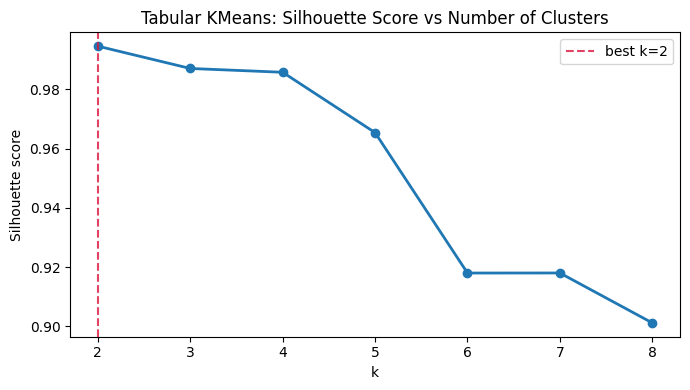

In [36]:
# Method 1 visuals: Tabular KMeans summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------- Visual 1: Silhouette score vs k ----------
score_dir = Path("output-csv/jwst_unsupervised")
score_candidates = [
    score_dir / "jwst_unsup_cluster_scores.csv",
    score_dir / "jwst_unsup_clister_scores.csv",
]
sil_path = next((p for p in score_candidates if p.exists()), None)
if sil_path is None:
    raise FileNotFoundError(
        "Silhouette score file not found. Checked: " + ", ".join(str(p) for p in score_candidates)
    )

sil_df = pd.read_csv(sil_path)
required_cols = {"k", "silhouette"}
if not required_cols.issubset(sil_df.columns):
    raise ValueError(
        f"{sil_path} must contain columns {sorted(required_cols)}; found {list(sil_df.columns)}"
    )

sil_df = sil_df[["k", "silhouette"]].dropna().copy()
sil_df["k"] = sil_df["k"].astype(int)
sil_df["silhouette"] = sil_df["silhouette"].astype(float)
sil_df = sil_df.sort_values("k")

best_k_tab = int(sil_df.loc[sil_df["silhouette"].idxmax(), "k"])

plt.figure(figsize=(7, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o", linewidth=2)
plt.axvline(best_k_tab, linestyle="--", color="crimson", alpha=0.8, label=f"best k={best_k_tab}")
plt.title("Tabular KMeans: Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.xticks(sil_df["k"].tolist())
plt.legend()
plt.tight_layout()
plt.show()



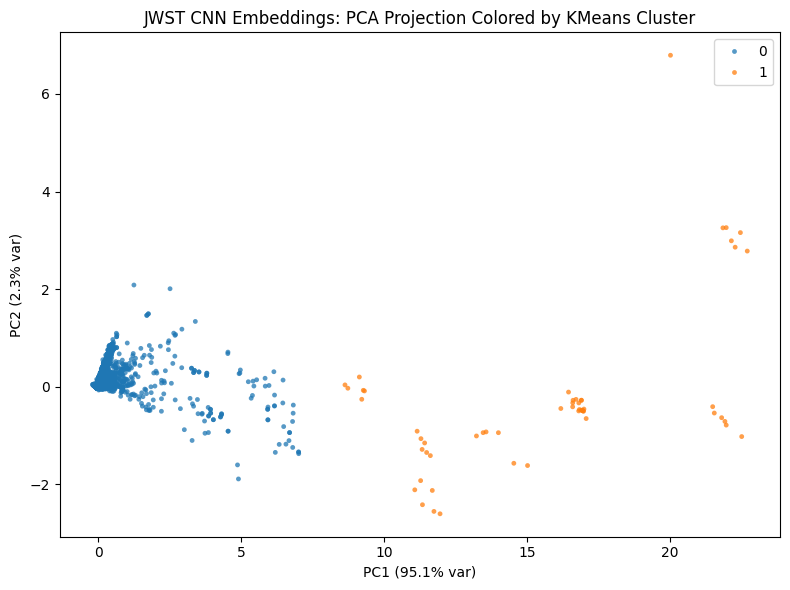

Loaded JWST cluster scores from: output-csv/jwst_unsupervised/jwst_unsup_cluster_scores.csv


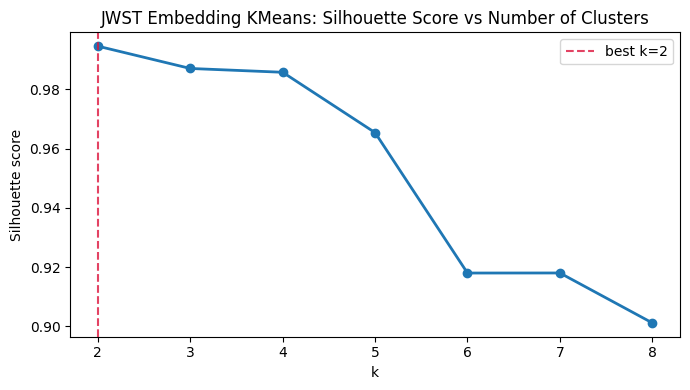

In [48]:
# Method 2 visuals: CNN-embedding KMeans summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

# Try to use in-memory embeddings if available; otherwise skip PCA scatter.
if "jwst_embeddings" in globals():
    jwst_embeddings = np.asarray(jwst_embeddings)
    has_embeddings = True
else:
    jwst_embeddings = None
    has_embeddings = False
    print("jwst_embeddings not in memory; skipping PCA embedding scatter.")

# Load cluster labels from memory or CSV.
if "jwst_cluster_labels" in globals():
    jwst_cluster_labels = np.asarray(jwst_cluster_labels)
else:
    labels_path = Path("output-csv/jwst_unsupervised/jwst_unsup_cluster_labels.csv")
    if not labels_path.exists():
        raise FileNotFoundError(
            f"jwst_cluster_labels not in memory and labels CSV not found at: {labels_path}"
        )

    labels_df = pd.read_csv(labels_path)
    required_cols = {"sample_idx", "cluster"}
    if not required_cols.issubset(labels_df.columns):
        raise KeyError(
            f"{labels_path} must contain columns {sorted(required_cols)}; found {list(labels_df.columns)}"
        )

    labels_df = labels_df.sort_values("sample_idx")
    jwst_cluster_labels = labels_df["cluster"].to_numpy()
    print(f"Loaded jwst_cluster_labels from: {labels_path}")

# ---------- Visual 1: 2D embedding scatter (PCA) ----------
if has_embeddings:
    if len(jwst_embeddings) != len(jwst_cluster_labels):
        print(
            f"Skipping PCA scatter: embeddings rows ({len(jwst_embeddings)}) "
            f"!= label count ({len(jwst_cluster_labels)})."
        )
    else:
        pca = PCA(n_components=2, random_state=42)
        emb_2d = pca.fit_transform(jwst_embeddings)

        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            x=emb_2d[:, 0],
            y=emb_2d[:, 1],
            hue=jwst_cluster_labels,
            palette="tab10",
            s=12,
            alpha=0.75,
            linewidth=0,
            legend="full",
        )
        plt.title("JWST CNN Embeddings: PCA Projection Colored by KMeans Cluster")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
        plt.tight_layout()
        plt.show()

# ---------- Visual 2: Silhouette score vs k (loaded from CSV if available) ----------
score_candidates = [
    Path("output-csv/jwst unsupervised/jwst_unsup_cluster_scores.csv"),
    Path("output-csv/jwst_unsupervised/jwst_unsup_cluster_scores.csv"),
    Path("output-scv/jwst unsupervised/jwst_unsup_cluster_scores.csv"),
    Path("jwst_unsup_cluster_scores.csv"),
]
score_path = next((p for p in score_candidates if p.exists()), None)

if score_path is not None:
    scores_df = pd.read_csv(score_path)
    print(f"Loaded JWST cluster scores from: {score_path}")
elif "cluster_scores" in globals():
    scores_df = pd.DataFrame(cluster_scores).copy()
    print("Using in-memory cluster_scores dataframe.")
else:
    raise FileNotFoundError(
        "Could not find jwst_unsup_cluster_scores.csv in expected folders, "
        "and cluster_scores is not in memory."
    )

required_cols = {"k", "silhouette"}
if not required_cols.issubset(scores_df.columns):
    raise KeyError(f"Scores file must contain columns: {required_cols}")

scores_df = scores_df.sort_values("k")
best_k = int(scores_df.loc[scores_df["silhouette"].idxmax(), "k"])

plt.figure(figsize=(7, 4))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o", linewidth=2)
plt.axvline(best_k, linestyle="--", color="crimson", alpha=0.8, label=f"best k={best_k}")
plt.title("JWST Embedding KMeans: Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.xticks(scores_df["k"].tolist())
plt.legend()
plt.tight_layout()
plt.show()

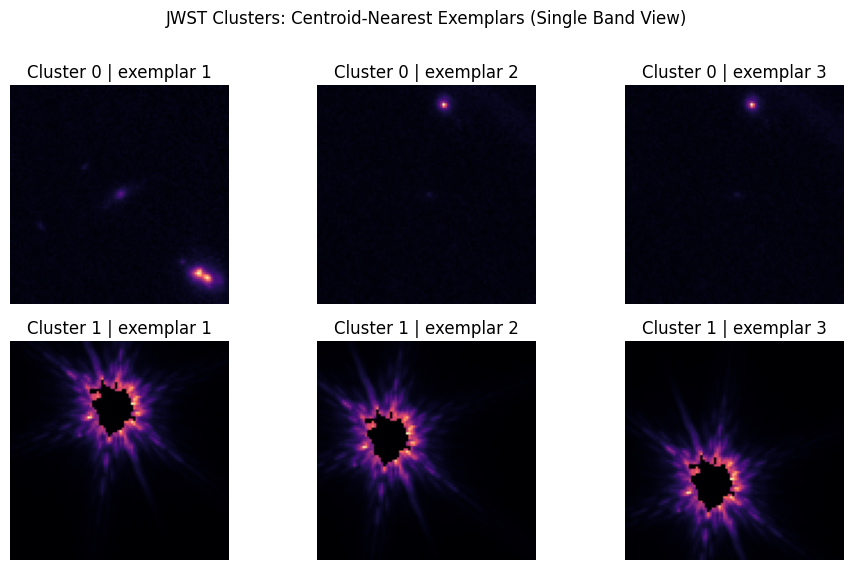

In [50]:
# Method 2 additional visual: exemplar images nearest each cluster centroid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "jwst_dataset" not in globals():
    raise RuntimeError("jwst_dataset not found. Run the JWST dataset-loading cell first.")

# Load cluster labels from memory or CSV.
if "jwst_cluster_labels" in globals():
    labels = np.asarray(jwst_cluster_labels)
else:
    labels_path = Path("output-csv/jwst_unsupervised/jwst_unsup_cluster_labels.csv")
    if not labels_path.exists():
        raise FileNotFoundError(f"Cluster labels CSV not found at: {labels_path}")

    labels_df = pd.read_csv(labels_path)
    required_cols = {"sample_idx", "cluster"}
    if not required_cols.issubset(labels_df.columns):
        raise KeyError(
            f"{labels_path} must contain columns {sorted(required_cols)}; found {list(labels_df.columns)}"
        )

    labels_df = labels_df.sort_values("sample_idx")
    labels = labels_df["cluster"].to_numpy()
    print(f"Loaded cluster labels from: {labels_path}")

# Try to use embeddings if available to pick centroid-nearest exemplars.
X = None
if "jwst_embeddings" in globals():
    X = np.asarray(jwst_embeddings)
else:
    emb_candidates = [
        Path("output-csv/jwst_unsupervised/jwst_embeddings.npy"),
        Path("jwst_embeddings.npy"),
    ]
    emb_path = next((p for p in emb_candidates if p.exists()), None)
    if emb_path is not None:
        X = np.load(emb_path)
        print(f"Loaded embeddings from: {emb_path}")

n_examples_per_cluster = 3
# Choose one informative band for compact plotting (index 2 usually F150W if ordering is standard)
band_idx = 2

cluster_ids = np.sort(pd.unique(labels))
n_clusters = len(cluster_ids)
fig, axes = plt.subplots(n_clusters, n_examples_per_cluster, figsize=(3.2 * n_examples_per_cluster, 2.8 * n_clusters))
if n_clusters == 1:
    axes = np.array([axes])

for row_idx, c in enumerate(cluster_ids):
    cluster_idx = np.where(labels == c)[0]
    if len(cluster_idx) == 0:
        for j in range(n_examples_per_cluster):
            axes[row_idx, j].axis("off")
        continue

    if X is not None and len(X) == len(labels):
        centroid = X[cluster_idx].mean(axis=0)
        d = np.linalg.norm(X[cluster_idx] - centroid, axis=1)
        nearest_local = np.argsort(d)[:n_examples_per_cluster]
        exemplar_idx = cluster_idx[nearest_local]
    else:
        exemplar_idx = cluster_idx[:n_examples_per_cluster]

    for j in range(n_examples_per_cluster):
        ax = axes[row_idx, j]
        if j < len(exemplar_idx):
            sample_idx = int(exemplar_idx[j])
            sample = jwst_dataset[sample_idx]
            if isinstance(sample, (tuple, list)):
                sample = sample[0]

            img = np.asarray(sample)
            if img.ndim == 3 and band_idx < img.shape[0]:
                view = img[band_idx]
            elif img.ndim == 2:
                view = img
            else:
                view = img[0] if img.ndim == 3 else np.squeeze(img)

            ax.imshow(view, cmap="magma", origin="lower")
            ax.set_title(f"Cluster {c} | exemplar {j+1}")
            ax.axis("off")
        else:
            ax.axis("off")

if X is not None and len(X) == len(labels):
    title = "JWST Clusters: Centroid-Nearest Exemplars (Single Band View)"
else:
    title = "JWST Clusters: Example Images per Cluster (Single Band View)"
plt.suptitle(title, y=1.01)
plt.tight_layout()
plt.show()

PCA plot of DCSCAN clusters on JWST dataset

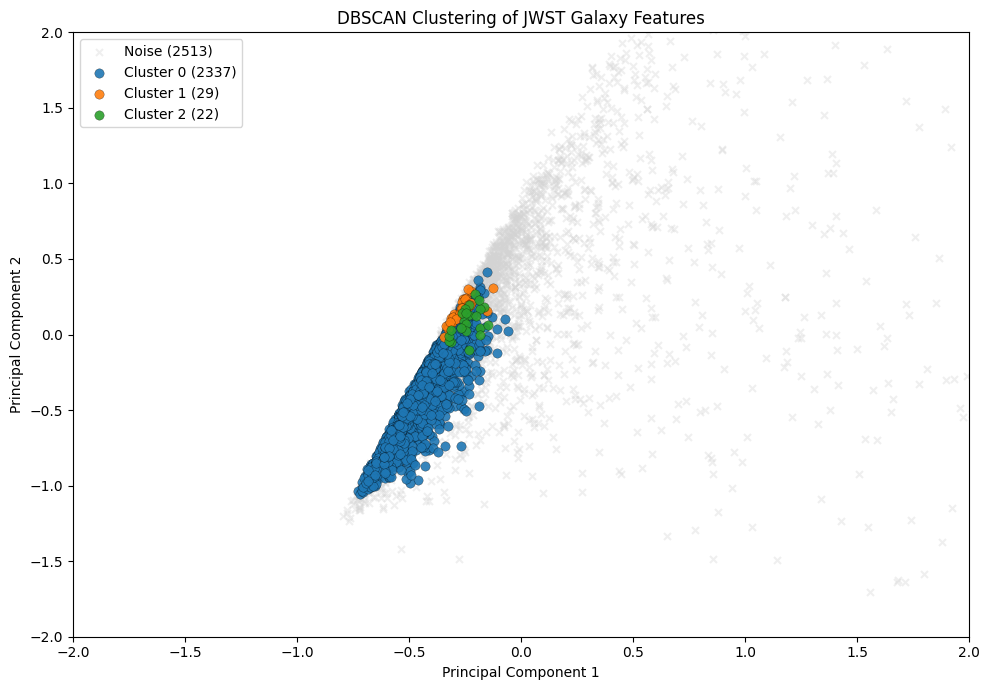

In [126]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

noise_mask = clusters == -1
plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c="lightgray",
    marker="x",
    s=25,
    alpha=0.35,
    label=f"Noise ({noise_mask.sum()})"
)

plt.xlim(-2, 2)
plt.ylim(-2, 2)

for cluster_id, color in zip([0, 1, 2], ["tab:blue", "tab:orange", "tab:green"]):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        s=45,
        alpha=0.9,
        label=f"Cluster {cluster_id} ({mask.sum()})",
        edgecolors="black",
        linewidths=0.2
    )

plt.title("DBSCAN Clustering of JWST Galaxy Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## Unsupervised Evaluation Summary (Report-Ready)

### Metric Choice and Justification

We evaluate unsupervised methods with metrics that do not require labels:

- **Silhouette score** (higher is better): measures cluster compactness and separation.
- **Davies-Bouldin Index** (lower is better): penalizes overlapping clusters.
- **Calinski-Harabasz score** (higher is better): rewards well-separated dense clusters.
- **Noise fraction** for DBSCAN (lower is usually better, but some noise can be desirable): fraction of points labeled as noise (`-1`).

Because methods use different representations (tabular morphology/photometry vs CNN embeddings), we report each method-family result separately and compare best model per family in one table.

### Sensitivity Analysis

We perform a sensitivity analysis on **DBSCAN** by sweeping `eps` and `min_samples`, then tracking silhouette, number of clusters, and noise fraction. This shows how stable conclusions are to parameter choices.

Reconstructed DBSCAN inputs using columns: ['g_ellipticity', 'r_ellipticity', 'i_ellipticity', 'z_ellipticity', 'y_ellipticity', 'specz_redshift']
Saved: unsupervised_overall_summary.csv


,Method Family,Representation,Best Silhouette,Davies-Bouldin,Calinski-Harabasz,Clusters,Noise Fraction
1,CNN-embedding KMeans,CNN embedding vectors,0.993720,NaN,NaN,2,0.000000
0,Tabular KMeans,Photometric + morphology tabular features,0.336601,1.157842,30006.739791,2,0.000000
2,DBSCAN,Tabular morphology/flux features,NaN,NaN,NaN,1,0.278395


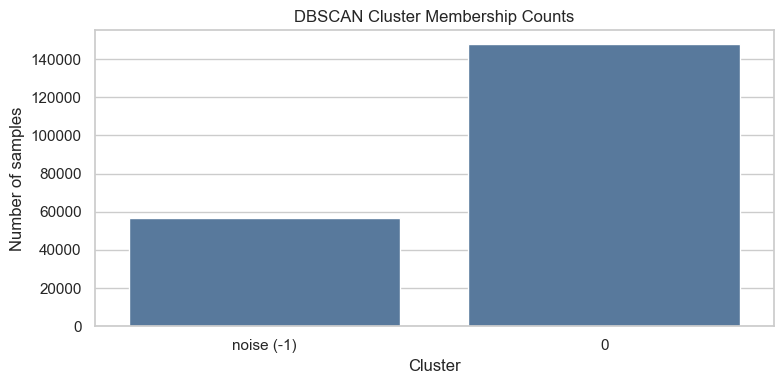

Saved: dbscan_sensitivity_analysis.csv


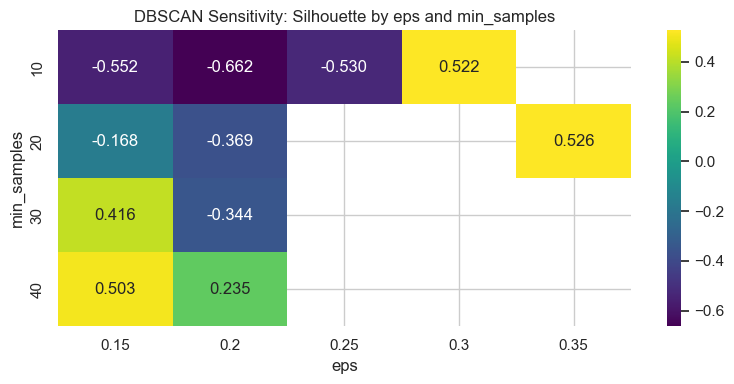

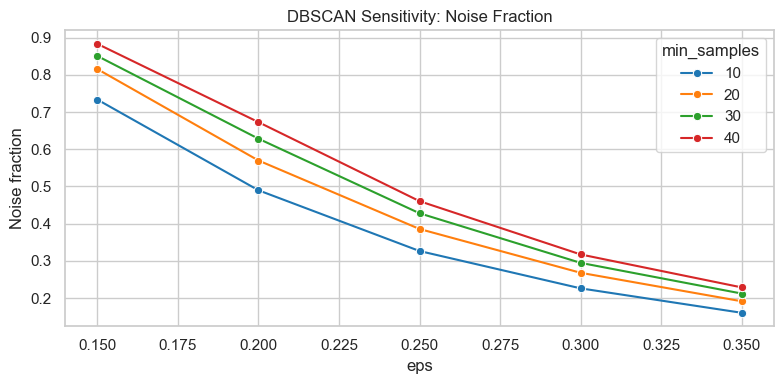

In [69]:
# Unsupervised overall summary + DBSCAN sensitivity analysis
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

rng = np.random.default_rng(42)

def _sample_idx(n, cap=60000):
    if n <= cap:
        return np.arange(n)
    return rng.choice(n, size=cap, replace=False)

summary_rows = []

# ---------- Method family 1: Tabular KMeans ----------
tab_metrics = {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan, "n_clusters": np.nan}
if "labeled_images_df" in globals() and isinstance(labeled_images_df, pd.DataFrame):
    candidate_features = [
        "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
        "g_ellipticity", "r_ellipticity", "i_ellipticity", "z_ellipticity", "y_ellipticity",
        "specz_redshift",
    ]
    tab_features = [c for c in candidate_features if c in labeled_images_df.columns]

    if len(tab_features) >= 3:
        tab_df = labeled_images_df[tab_features].replace([np.inf, -np.inf], np.nan).dropna()
        if len(tab_df) > 50:
            X_tab_full = StandardScaler().fit_transform(tab_df.to_numpy(dtype=float))
            idx = _sample_idx(len(X_tab_full), cap=50000)
            X_tab = X_tab_full[idx]

            best = None
            for k in range(2, 9):
                km = KMeans(n_clusters=k, n_init=20, random_state=42)
                yk = km.fit_predict(X_tab)
                sil = silhouette_score(X_tab, yk)
                dbi = davies_bouldin_score(X_tab, yk)
                ch = calinski_harabasz_score(X_tab, yk)
                row = {
                    "k": k,
                    "silhouette": float(sil),
                    "davies_bouldin": float(dbi),
                    "calinski_harabasz": float(ch),
                }
                if best is None or row["silhouette"] > best["silhouette"]:
                    best = row

            if best is not None:
                tab_metrics = {
                    "silhouette": best["silhouette"],
                    "davies_bouldin": best["davies_bouldin"],
                    "calinski_harabasz": best["calinski_harabasz"],
                    "n_clusters": best["k"],
                }

summary_rows.append({
    "Method Family": "Tabular KMeans",
    "Representation": "Photometric + morphology tabular features",
    "Best Silhouette": tab_metrics["silhouette"],
    "Davies-Bouldin": tab_metrics["davies_bouldin"],
    "Calinski-Harabasz": tab_metrics["calinski_harabasz"],
    "Clusters": tab_metrics["n_clusters"],
    "Noise Fraction": 0.0,
})

# ---------- Method family 2: CNN-embedding KMeans ----------
emb_metrics = {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan, "n_clusters": np.nan}
labels_csv = Path("output-csv/jwst_unsupervised/jwst_unsup_cluster_labels.csv")
scores_csv = Path("output-csv/jwst_unsupervised/jwst_unsup_cluster_scores.csv")

emb_X = None
emb_labels = None
if "jwst_embeddings" in globals():
    emb_X = np.asarray(jwst_embeddings)
if "jwst_cluster_labels" in globals():
    emb_labels = np.asarray(jwst_cluster_labels)
elif labels_csv.exists():
    emb_labels = pd.read_csv(labels_csv).sort_values("sample_idx")["cluster"].to_numpy()

if emb_X is not None and emb_labels is not None and len(emb_X) == len(emb_labels):
    idx = _sample_idx(len(emb_X), cap=50000)
    Xs = emb_X[idx]
    ys = emb_labels[idx]
    if len(np.unique(ys)) > 1:
        emb_metrics["silhouette"] = float(silhouette_score(Xs, ys))
        emb_metrics["davies_bouldin"] = float(davies_bouldin_score(Xs, ys))
        emb_metrics["calinski_harabasz"] = float(calinski_harabasz_score(Xs, ys))
        emb_metrics["n_clusters"] = int(len(np.unique(ys)))
elif scores_csv.exists():
    sc = pd.read_csv(scores_csv)
    if {"k", "silhouette"}.issubset(sc.columns):
        best_row = sc.loc[sc["silhouette"].idxmax()]
        emb_metrics["silhouette"] = float(best_row["silhouette"])
        emb_metrics["n_clusters"] = int(best_row["k"])

summary_rows.append({
    "Method Family": "CNN-embedding KMeans",
    "Representation": "CNN embedding vectors",
    "Best Silhouette": emb_metrics["silhouette"],
    "Davies-Bouldin": emb_metrics["davies_bouldin"],
    "Calinski-Harabasz": emb_metrics["calinski_harabasz"],
    "Clusters": emb_metrics["n_clusters"],
    "Noise Fraction": 0.0,
})

# ---------- Build DBSCAN inputs (reuse existing or reconstruct) ----------
X_db_global = None
clusters_global = None
if "X_scaled" in globals() and "clusters" in globals():
    X_db_global = np.asarray(X_scaled)
    clusters_global = np.asarray(clusters)
else:
    feature_pools = [
        ["a_image", "b_image", "ellipticity", "theta_image", "mean_flux", "std_flux", "max_flux"],
        ["g_ellipticity", "r_ellipticity", "i_ellipticity", "z_ellipticity", "y_ellipticity", "specz_redshift"],
        ["g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag", "specz_redshift"],
    ]

    candidate_frames = []
    for nm in ["jwst_df", "images_morphology_df", "labeled_images_df"]:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            candidate_frames.append(globals()[nm])

    data_candidates = [
        Path("data/5x127x127_training_with_morphology.csv"),
        Path("data/5x127x127_validation_with_morphology.csv"),
        Path("data/5x127x127_testing_with_morphology.csv"),
    ]
    for p in data_candidates:
        if p.exists():
            try:
                candidate_frames.append(pd.read_csv(p))
            except Exception:
                pass

    built = False
    for df in candidate_frames:
        for pool in feature_pools:
            available = [c for c in pool if c in df.columns]
            if len(available) >= 5:
                db_df = df[available].replace([np.inf, -np.inf], np.nan).dropna()
                if len(db_df) > 50:
                    X_np = np.ascontiguousarray(db_df.to_numpy(dtype=float))
                    X_db_global = StandardScaler().fit_transform(X_np)
                    clusters_global = DBSCAN(eps=0.25, min_samples=30).fit_predict(X_db_global)
                    built = True
                    print(f"Reconstructed DBSCAN inputs using columns: {available}")
                    break
        if built:
            break

    if not built:
        print("Could not reconstruct DBSCAN inputs from available dataframes or data CSV files.")

# ---------- Method family 3: DBSCAN ----------
dbscan_metrics = {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan, "n_clusters": np.nan, "noise_fraction": np.nan}
if X_db_global is not None and clusters_global is not None:
    non_noise = clusters_global != -1
    n_clusters = len(np.unique(clusters_global[non_noise])) if np.any(non_noise) else 0
    noise_fraction = float(np.mean(clusters_global == -1))

    if np.any(non_noise) and n_clusters > 1:
        X_eval = X_db_global[non_noise]
        y_eval = clusters_global[non_noise]
        idx = _sample_idx(len(X_eval), cap=50000)
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]
        dbscan_metrics["silhouette"] = float(silhouette_score(X_eval, y_eval))
        dbscan_metrics["davies_bouldin"] = float(davies_bouldin_score(X_eval, y_eval))
        dbscan_metrics["calinski_harabasz"] = float(calinski_harabasz_score(X_eval, y_eval))

    dbscan_metrics["n_clusters"] = int(n_clusters)
    dbscan_metrics["noise_fraction"] = noise_fraction

summary_rows.append({
    "Method Family": "DBSCAN",
    "Representation": "Tabular morphology/flux features",
    "Best Silhouette": dbscan_metrics["silhouette"],
    "Davies-Bouldin": dbscan_metrics["davies_bouldin"],
    "Calinski-Harabasz": dbscan_metrics["calinski_harabasz"],
    "Clusters": dbscan_metrics["n_clusters"],
    "Noise Fraction": dbscan_metrics["noise_fraction"],
})

unsup_overall_summary = pd.DataFrame(summary_rows)
unsup_overall_summary = unsup_overall_summary.sort_values("Best Silhouette", ascending=False, na_position="last")
unsup_overall_summary.to_csv("unsupervised_overall_summary.csv", index=False)

print("Saved: unsupervised_overall_summary.csv")
display(unsup_overall_summary)

# ---------- Additional DBSCAN visual (2nd DBSCAN visual) ----------
if clusters_global is not None:
    cls = pd.Series(clusters_global, name="cluster")
    dist_df = cls.value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
    dist_df["cluster_label"] = dist_df["cluster"].astype(str)
    dist_df.loc[dist_df["cluster"] == -1, "cluster_label"] = "noise (-1)"

    plt.figure(figsize=(8, 4))
    sns.barplot(data=dist_df, x="cluster_label", y="count", color="#4C78A8")
    plt.title("DBSCAN Cluster Membership Counts")
    plt.xlabel("Cluster")
    plt.ylabel("Number of samples")
    plt.tight_layout()
    plt.show()

# ---------- Sensitivity analysis on DBSCAN ----------
if X_db_global is not None:
    idx = _sample_idx(len(X_db_global), cap=50000)
    X_sub = X_db_global[idx]

    eps_grid = [0.15, 0.20, 0.25, 0.30, 0.35]
    min_samples_grid = [10, 20, 30, 40]
    sens_rows = []

    for eps in eps_grid:
        for ms in min_samples_grid:
            model = DBSCAN(eps=eps, min_samples=ms)
            y_hat = model.fit_predict(X_sub)
            non_noise = y_hat != -1
            n_clusters = len(np.unique(y_hat[non_noise])) if np.any(non_noise) else 0
            noise_frac = float(np.mean(y_hat == -1))
            sil = np.nan
            if np.any(non_noise) and n_clusters > 1:
                sil = float(silhouette_score(X_sub[non_noise], y_hat[non_noise]))

            sens_rows.append({
                "eps": eps,
                "min_samples": ms,
                "n_clusters": int(n_clusters),
                "noise_fraction": noise_frac,
                "silhouette": sil,
            })

    dbscan_sensitivity = pd.DataFrame(sens_rows)
    dbscan_sensitivity.to_csv("dbscan_sensitivity_analysis.csv", index=False)
    print("Saved: dbscan_sensitivity_analysis.csv")

    sil_pivot = dbscan_sensitivity.pivot(index="min_samples", columns="eps", values="silhouette")
    plt.figure(figsize=(8, 4))
    sns.heatmap(sil_pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title("DBSCAN Sensitivity: Silhouette by eps and min_samples")
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.lineplot(
        data=dbscan_sensitivity,
        x="eps",
        y="noise_fraction",
        hue="min_samples",
        marker="o",
        palette="tab10",
    )
    plt.title("DBSCAN Sensitivity: Noise Fraction")
    plt.xlabel("eps")
    plt.ylabel("Noise fraction")
    plt.tight_layout()
    plt.show()